# Exercise 1.B - Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# For displaying Jupyter notebooks on Retina displays
%config InlineBackend.figure_format = 'retina'

In [2]:
# some styling for the plots
import matplotlib

plt.style.use('seaborn-v0_8-darkgrid')

DEFAULT_SIZE = 14

plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = DEFAULT_SIZE
plt.rcParams["axes.titlesize"] = DEFAULT_SIZE
plt.rcParams["axes.labelsize"] = DEFAULT_SIZE
plt.rcParams["xtick.labelsize"] = DEFAULT_SIZE
plt.rcParams["ytick.labelsize"] = DEFAULT_SIZE

## Step 1 - Cleaning of the Movies Metadata


From the dataset, keep the following:
- id
- title
- vote_counts
- runtime
- vote_average
- revenue
- budget
- release_date
- genres

In [4]:
df = pd.read_csv('../data/movies_metadata.csv')
df.head()

/tmp/ipykernel_331333/3131793673.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re



When we load the data into the dateframe, pandas warns us that column 10 ('popularity') contains multiple datatypes. Indeed, in the discussion of this dataset in Kaggle, it is also mentioned that there exists a string value.

We will fix it and also clean some other of our data. Lets keep the data we need in a copy of the original dataset.

In [6]:
columns = ['id', 'title', 'vote_count', 'runtime', 'vote_average', 'revenue', 'budget', 'release_date', 'genres']
data = df[columns]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            45466 non-null  object 
 1   title         45460 non-null  object 
 2   vote_count    45460 non-null  float64
 3   runtime       45203 non-null  float64
 4   vote_average  45460 non-null  float64
 5   revenue       45460 non-null  float64
 6   budget        45466 non-null  object 
 7   release_date  45379 non-null  object 
 8   genres        45466 non-null  object 
dtypes: float64(4), object(5)
memory usage: 3.1+ MB


Now we are ready to start pre-processing and cleaning the **metadata** dataset. We will take the following actions:
- Rename some columns
- Find duplicates if any in the dataset and remove them
- Drop any rows with missing values, after examining where they exist
- Convert columns to appropriate datatypes
- Handle other problems that may arise in the process

In [7]:
# renaming runtime to duration
data = data.rename(columns={'runtime': 'duration'})
data.columns

Index(['id', 'title', 'vote_count', 'duration', 'vote_average', 'revenue',
       'budget', 'release_date', 'genres'],
      dtype='object')

We will start our examination by looking for duplicate rows.

In [8]:
print(f'Sum of all entries: {data.shape[0]}')
print(f'Sum of duplicate entries: {data.duplicated().sum()}')

Sum of all entries: 45466
Sum of duplicate entries: 28


Indeed, we find 28 duplicate rows in our dataset, we will simply remove them.

In [9]:
data = data.drop_duplicates()
print(f'After removing dyplicate entries: {data.shape[0]}')

After removing dyplicate entries: 45438


We move forward with examining how many null values exist in each category.

In [10]:
print(f'Sum of null entries per column:\n\n{data.isnull().sum()}')

Sum of null entries per column:

id                0
title             6
vote_count        6
duration        263
vote_average      6
revenue           6
budget            0
release_date     87
genres            0
dtype: int64


Most of the missing values exist on ``duration`` and ``release_date``, we will simply remove them, since they are not that many to make an impact in our analysis.

In [11]:
data = data.dropna()
print(f'Number of entries after dropping entries with null values: {data.shape[0]}')

Number of entries after dropping entries with null values: 45102


We move forward by examining the datatypes of our dataset and making the needed conversions.

In [12]:
print(f'Datatypes of columns:\n\n{data.dtypes}')

Datatypes of columns:

id               object
title            object
vote_count      float64
duration        float64
vote_average    float64
revenue         float64
budget           object
release_date     object
genres           object
dtype: object


We will change ``vote_count`` to ``int``, ``duration`` to ``int``, ``revenue`` to ``int``, ``budget`` to ``int`` and ``release_date`` to ``datetime``.

In [13]:
data.vote_count = data.vote_count.astype(int)
data.duration = data.duration.astype(int)
data.revenue = data.revenue.astype(int)
data.budget = data.budget.astype(int)
data.release_date = pd.to_datetime(data.release_date)

print(f'New datatypes:\n\n{data.dtypes}')

New datatypes:

id                      object
title                   object
vote_count               int64
duration                 int64
vote_average           float64
revenue                  int64
budget                   int64
release_date    datetime64[ns]
genres                  object
dtype: object


We will take it a bit further and examine the occurance of values of each of the categories ``budget``, ``vote_count``, ``duration`` and ``revenue``.

In [14]:
print(f'{data.budget.value_counts()}\n')
print(f'{data.vote_count.value_counts()}\n')
print(f'{data.duration.value_counts()}\n')
print(f'{data.revenue.value_counts()}\n')

budget
0           36234
5000000       286
10000000      258
20000000      243
2000000       241
            ...  
41677699        1
11715578        1
9750000         1
7275000         1
152000          1
Name: count, Length: 1219, dtype: int64

vote_count
1       3181
2       3091
3       2765
0       2754
4       2465
        ... 
1721       1
1059       1
448        1
2020       1
2169       1
Name: count, Length: 1820, dtype: int64

duration
90      2548
0       1535
100     1470
95      1409
93      1213
        ... 
1256       1
452        1
313        1
359        1
780        1
Name: count, Length: 353, dtype: int64

revenue
0           37709
12000000       20
11000000       19
10000000       19
2000000        18
            ...  
15073942        1
2807854         1
1942423         1
4245870         1
51001550        1
Name: count, Length: 6858, dtype: int64



We observe that the majority of ``budget`` and ``revenue`` columns consist of zero entries. That could be because the zeros represent unfilled fields, gathered from multiple sources, instead of them being filled with null values. Also, the ``duration`` column has a good proportion of zero entries also.

If we drop them from our dataset, we will be left with the following datapoints.

In [15]:
exp = data[
    (data.budget > 0) & (data.duration > 0) & (data.revenue > 0)]

print(f'Rows remaining after filtering zero values (possibly missing values, imputed with zeros): {exp.shape}')

Rows remaining after filtering zero values (possibly missing values, imputed with zeros): (5365, 9)


There is a significant reduction of the size of our dataset, we will proceed by examining the data distribution of the two datasets, and take a desicion on whether we will keep them or drop them.

In [16]:
print(f'{exp.budget.value_counts()}\n')
print(f'{exp.duration.value_counts()}\n')
print(f'{exp.revenue.value_counts()}\n')

budget
20000000    184
25000000    175
15000000    172
30000000    156
10000000    147
           ... 
3537415       1
4881000       1
1227401       1
37931000      1
2135161       1
Name: count, Length: 700, dtype: int64

duration
100    166
95     139
97     139
93     135
98     133
      ... 
62       1
320      1
180      1
26       1
57       1
Name: count, Length: 156, dtype: int64

revenue
12000000     16
2000000      15
11000000     15
10000000     15
6000000      12
             ..
171269535     1
358372926     1
145771527     1
5400000       1
12918858      1
Name: count, Length: 4998, dtype: int64



Now it seems from a simple ``value_counts`` operation, we are left with a "smoother" representation. 

We further investigate the difference in the distributions, in order to see how much zeros mess with the data distributions and we will decide if we will keep the filtered data of the data with the zeros.

<Axes: ylabel='Frequency'>

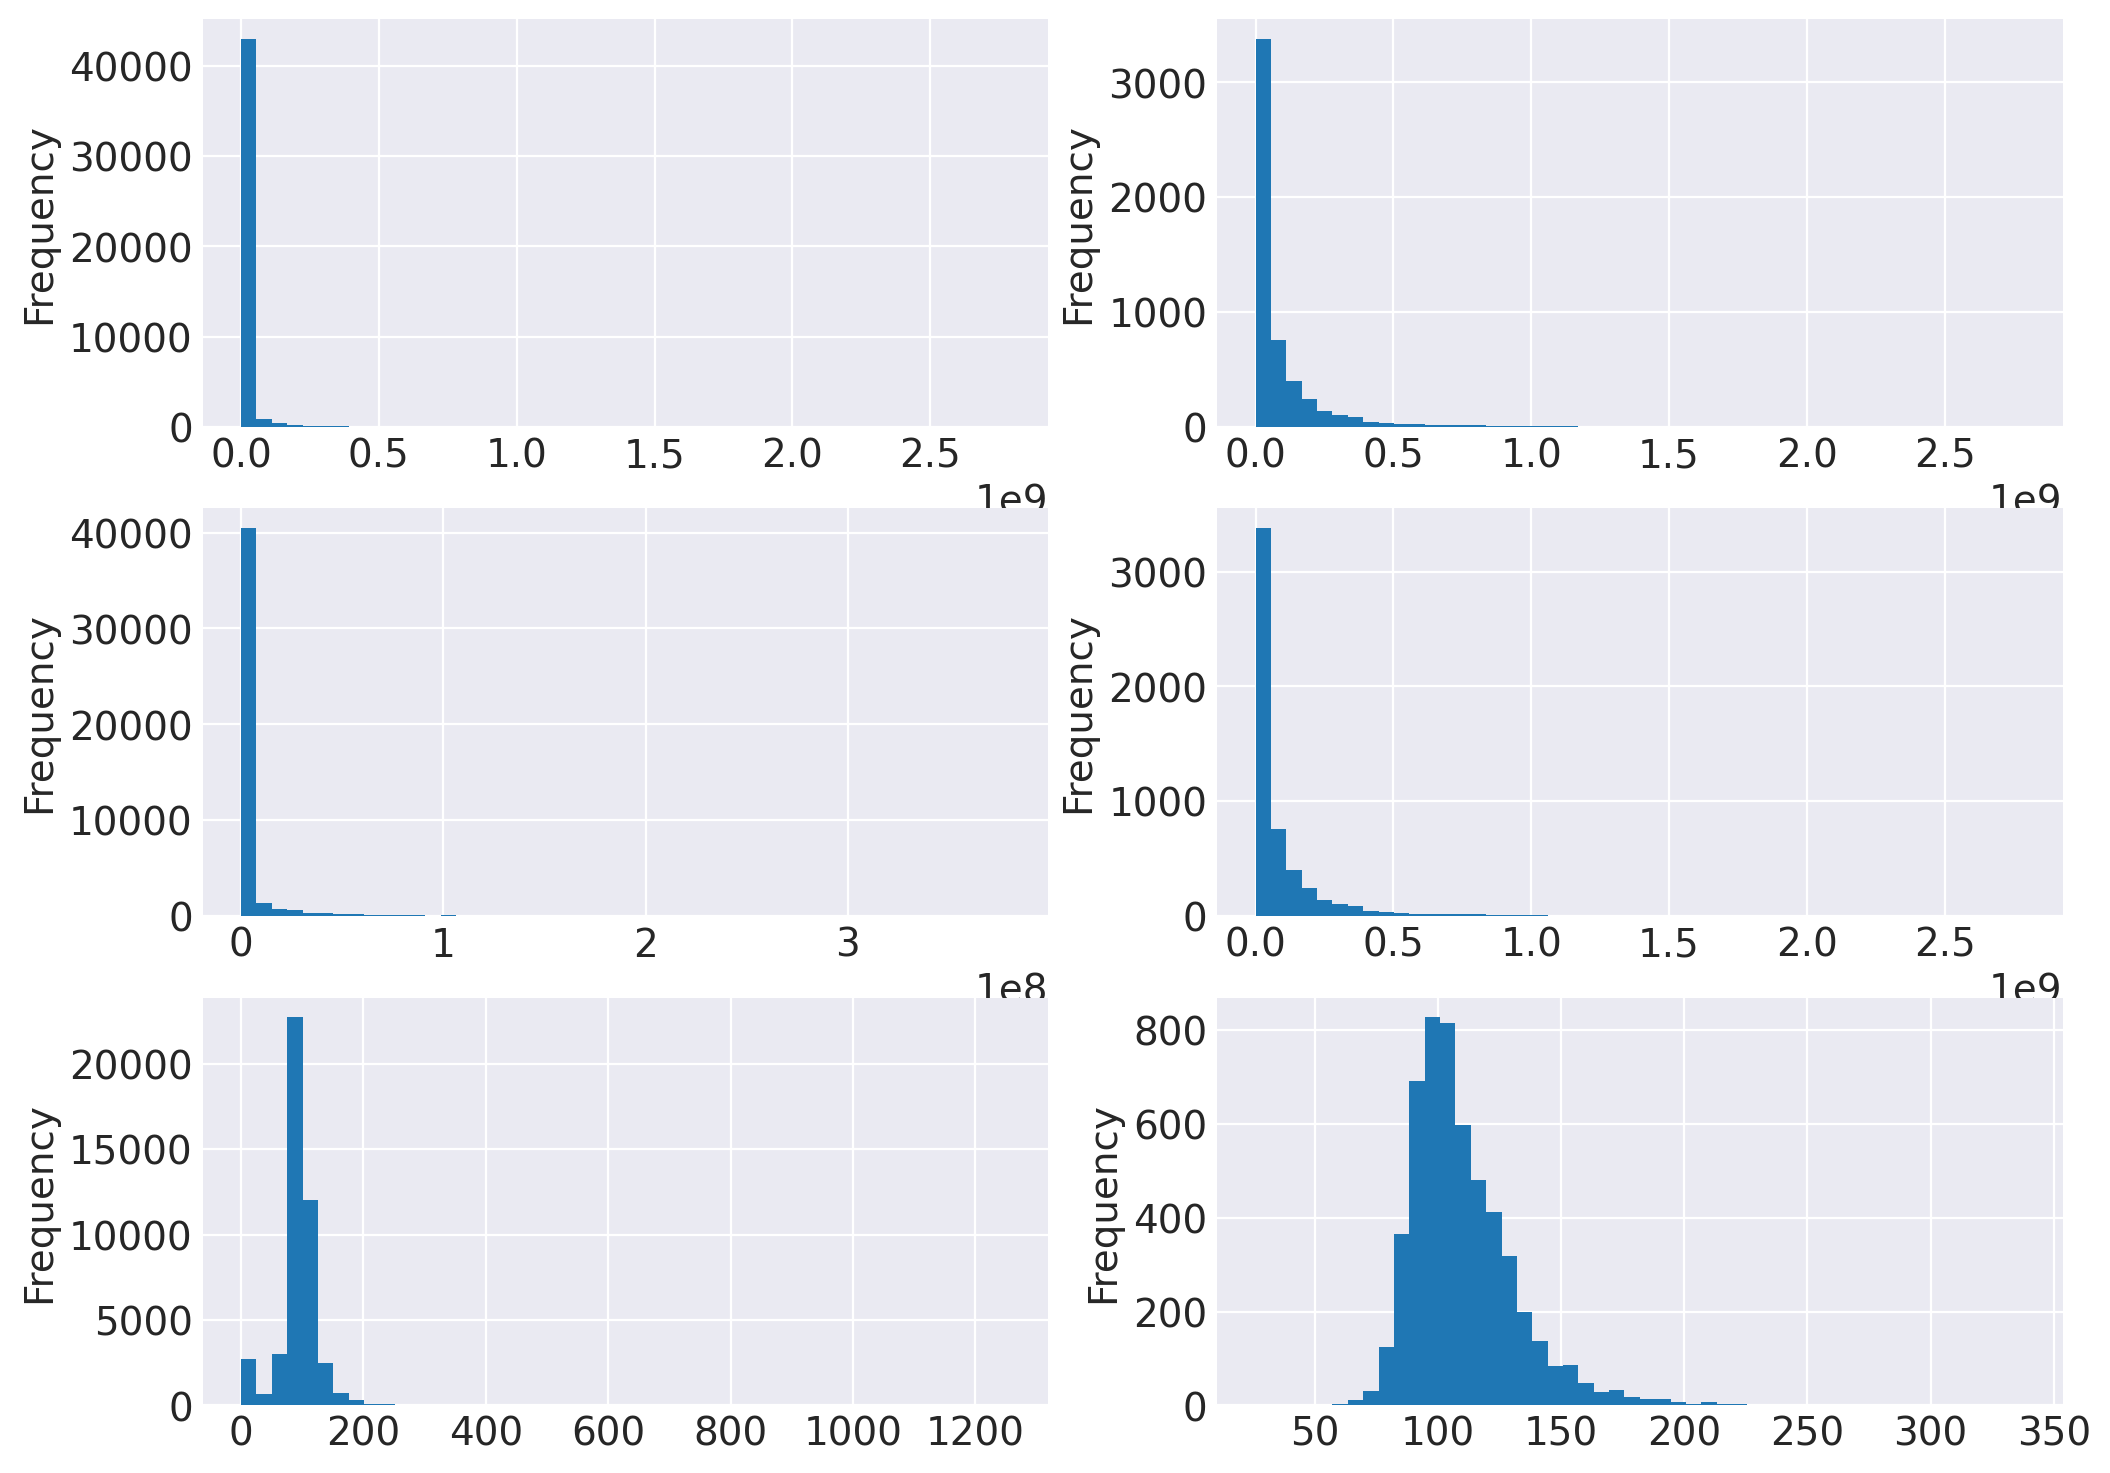

In [17]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12,9))
data.revenue.plot(kind='hist', ax=axs[0,0], bins=50)
exp.revenue.plot(kind='hist', ax=axs[0,1], bins=50)
data.budget.plot(kind='hist', ax=axs[1,0], bins=50)
exp.revenue.plot(kind='hist', ax=axs[1,1], bins=50)
data.duration.plot(kind='hist', ax=axs[2,0], bins=50)
exp.duration.plot(kind='hist', ax=axs[2,1], bins=50)

From the above, we see a significant shift in the distribution ``duration``, and slight but valuable shift in the distributions of ``budget`` and ``revenue``.  

We will now examing how descriptive statistics of these variables change.

In [18]:
print(f'Before filtering the dataset:\n{data.describe()[['budget', 'revenue', 'duration']]}')
print(f'After filtering the dataset:\n{exp.describe()[['budget', 'revenue', 'duration']]}')

Before filtering the dataset:
             budget       revenue      duration
count  4.510200e+04  4.510200e+04  45102.000000
mean   4.255953e+06  1.129672e+07     94.177775
min    0.000000e+00  0.000000e+00      0.000000
25%    0.000000e+00  0.000000e+00     85.000000
50%    0.000000e+00  0.000000e+00     95.000000
75%    0.000000e+00  0.000000e+00    107.000000
max    3.800000e+08  2.787965e+09   1256.000000
std    1.748850e+07  6.457924e+07     38.347925
After filtering the dataset:
             budget       revenue     duration
count  5.365000e+03  5.365000e+03  5365.000000
mean   3.116485e+07  9.057183e+07   110.055172
min    1.000000e+00  1.000000e+00    26.000000
25%    5.200000e+06  7.096000e+06    95.000000
50%    1.700000e+07  3.000000e+07   106.000000
75%    4.000000e+07  1.000000e+08   120.000000
max    3.800000e+08  2.787965e+09   338.000000
std    4.019758e+07  1.663242e+08    21.498494


From a quick look in the descriptive statistics we calculated, we see that they have changed and quite a lot in some variables, so we take the desicion to keep the filtered data, assuming that we have enough sample points to make. It is important to state that, the median and even the 75-th percentile values of ``budget`` and ``revenue`` before filtering the dataset were zero. This boosts our decision moving forwand.

In [19]:
data = exp
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5365 entries, 0 to 45422
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            5365 non-null   object        
 1   title         5365 non-null   object        
 2   vote_count    5365 non-null   int64         
 3   duration      5365 non-null   int64         
 4   vote_average  5365 non-null   float64       
 5   revenue       5365 non-null   int64         
 6   budget        5365 non-null   int64         
 7   release_date  5365 non-null   datetime64[ns]
 8   genres        5365 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 419.1+ KB


## Step 2 - Vote count distribution

We are interested to know what distribution does vote_counts follow (although we can already make a guess that it follows a power-law distribution). For the examination of this, we will do the following.


Most films receive few votes and some films receive too many votes, approaches a power-law distrubution.

Starting our investigation, we will produce a histogram with 100 equiwidth bins.

[Text(0.5, 1.0, 'Vote count histogram with 100 equiwidth bins'),
 Text(0.5, 0, 'Vote count value'),
 (0.0, 14075.0)]

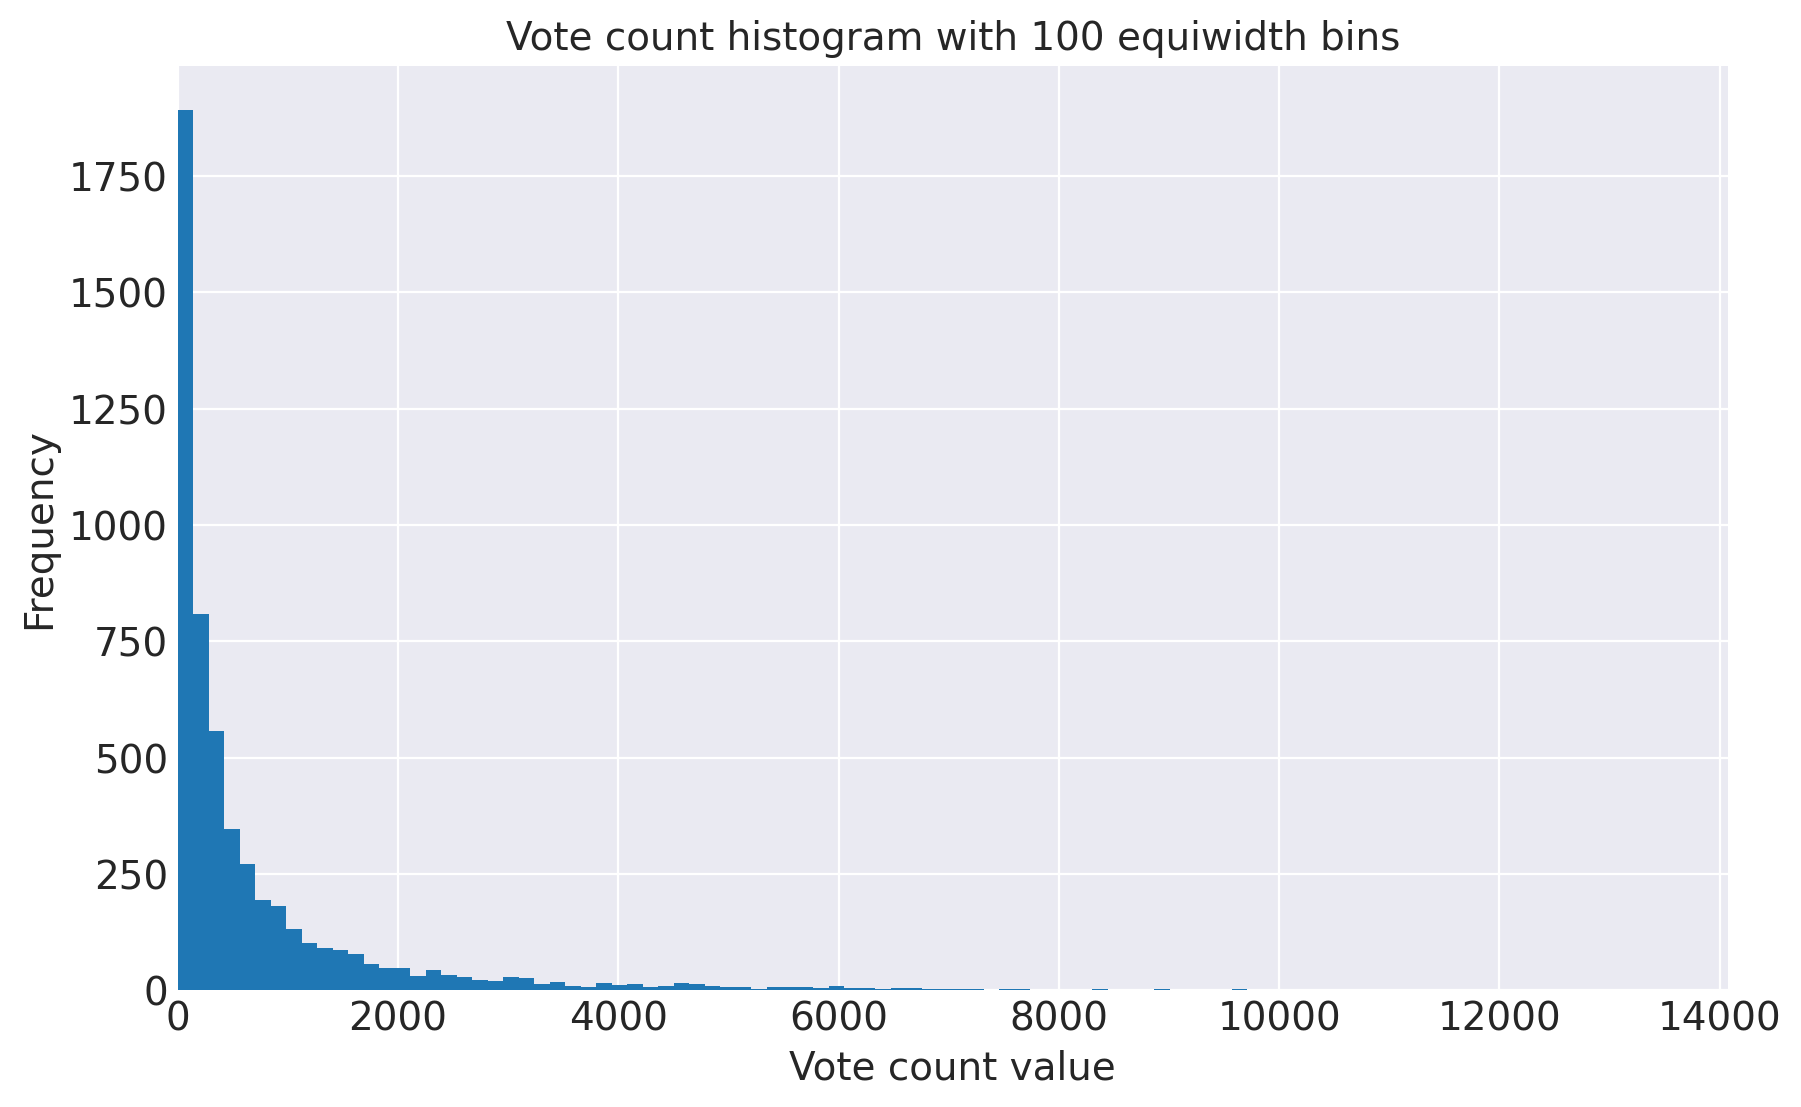

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
data['vote_count'].plot(kind='hist', bins=100, ax=ax)
ax.set(
    title="Vote count histogram with 100 equiwidth bins",
    xlabel="Vote count value",
    xlim=[0, data['vote_count'].max()]
)

We see a very skewed distribution, next we will try logarithmic binning, instead of equiwidth binning.
We will now create the bin list needed to provide to the Pandas ``.plot`` method in the ``bins`` argument. We will create two plots, one with logarithmic-scale axis and one with normal axis.

In [21]:
end = 100
max_val = data['vote_count'].max()
width=100

bin_seq = [0]
while end < max_val:
    end = bin_seq[-1]+width
    bin_seq.append(end)
    width = width*2

print(bin_seq)

[0, 100, 300, 700, 1500, 3100, 6300, 12700, 25500]


[Text(0.5, 1.0, 'Histogram using equilog binning'),
 Text(0.5, 0, 'Log scale vote count')]

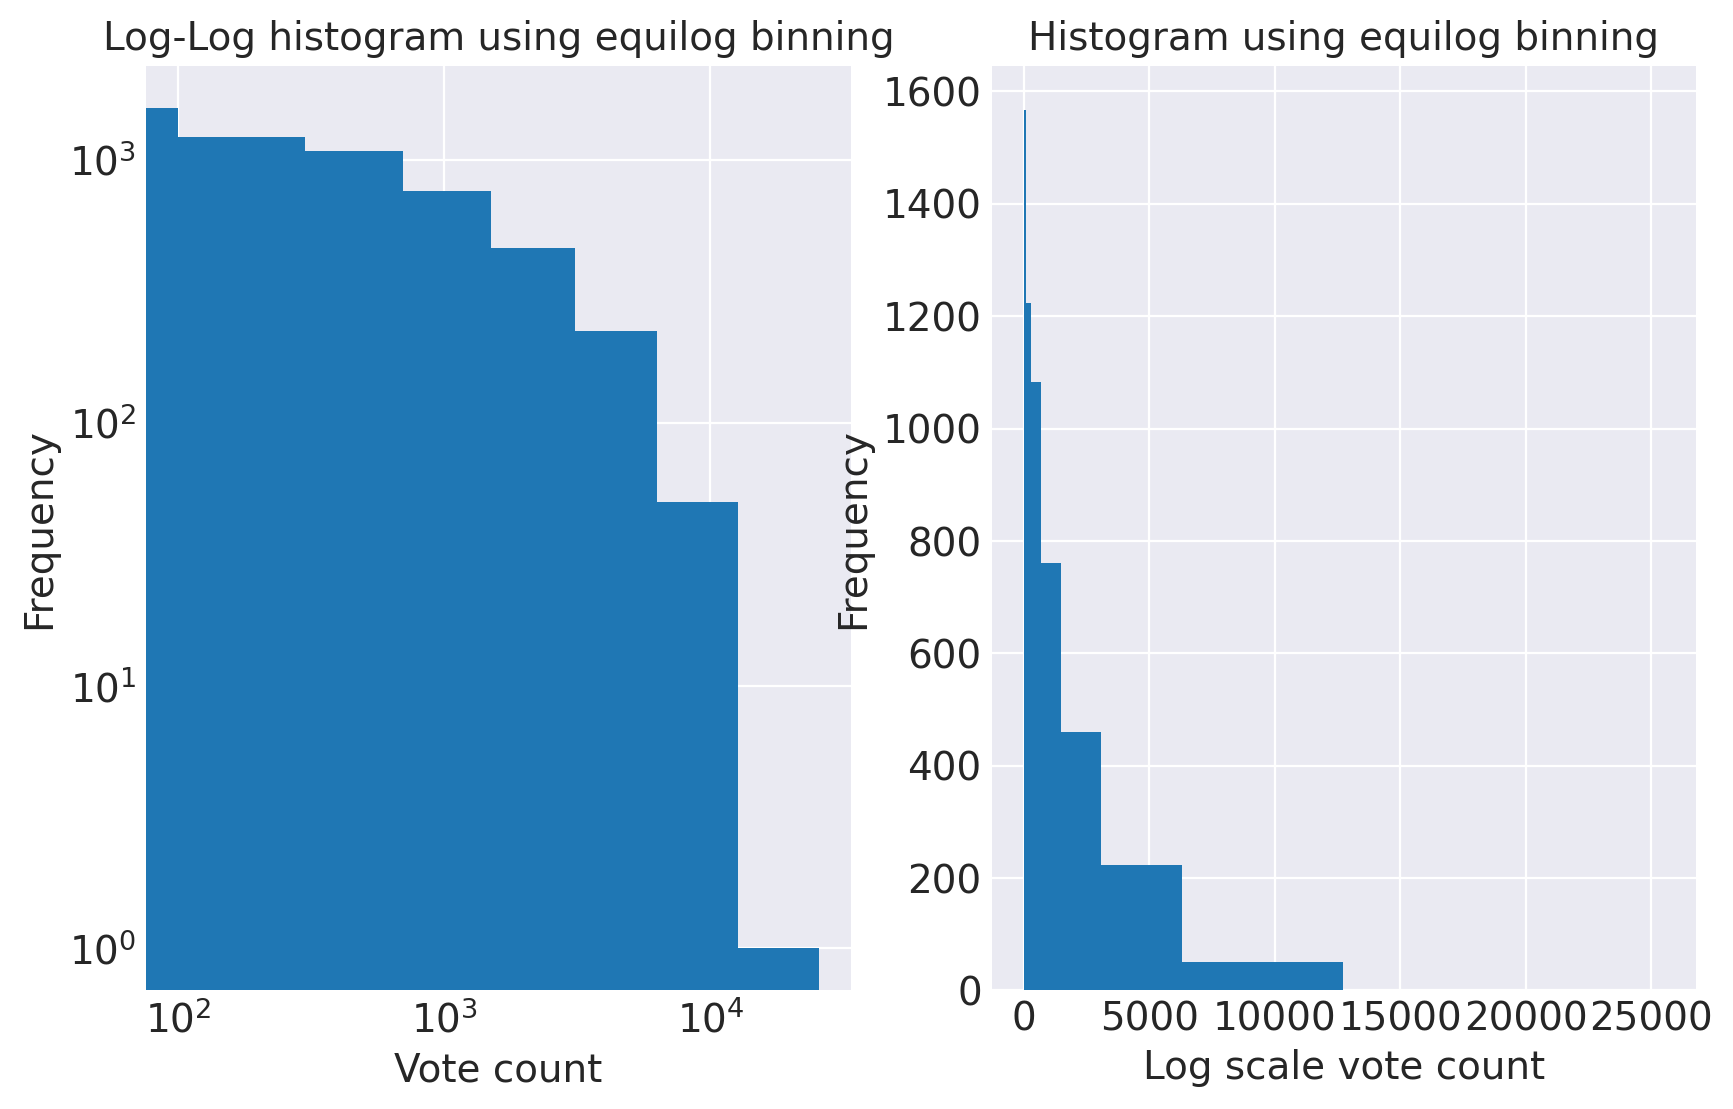

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
data['vote_count'].plot(kind='hist', ax=ax[0], bins=bin_seq)
ax[0].set(
    title="Log-Log histogram using equilog binning",
    xlabel="Vote count"
)
ax[0].loglog()
data['vote_count'].plot(kind='hist', ax=ax[1], bins=bin_seq)
ax[1].set(
    title="Histogram using equilog binning",
    xlabel="Log scale vote count"
)

[]

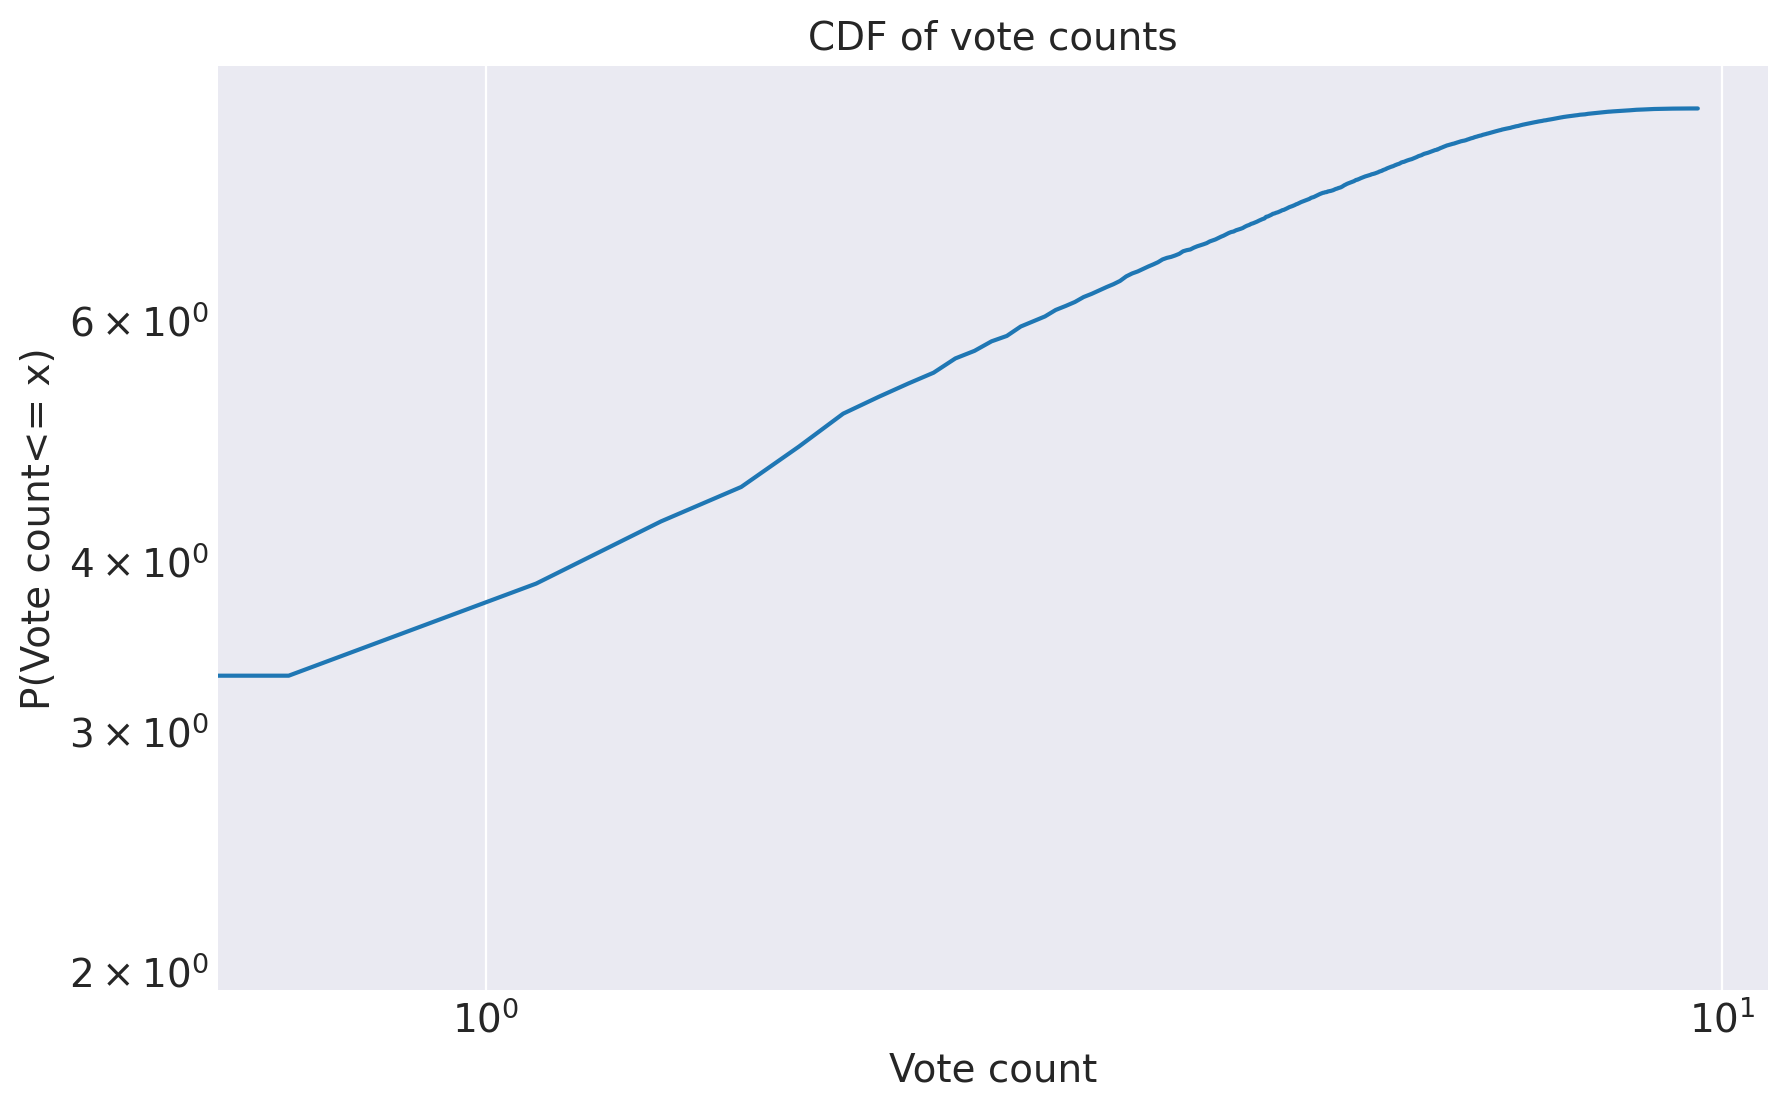

In [27]:

## Note: not what was asked, but found it more usefull

import numpy as np

x = data['vote_count'].sort_values()
x.to_numpy()
y=x.value_counts().sort_index().cumsum()

x = np.log(x+1)
y = np.log(y+1)

fig, ax = plt.subplots(figsize=(10,6))
plt.plot(x.unique(), y)
ax.set(
    title="CDF of vote counts",
    xlabel='Vote count',
    ylabel='P(Vote count<= x)'
)
ax.loglog()

We will now produce the **Zipf plot** for the vote count. In the Y axis, we have the number of votes and in X axis the rank of the values, which is the descending order of the vote count values.

[]

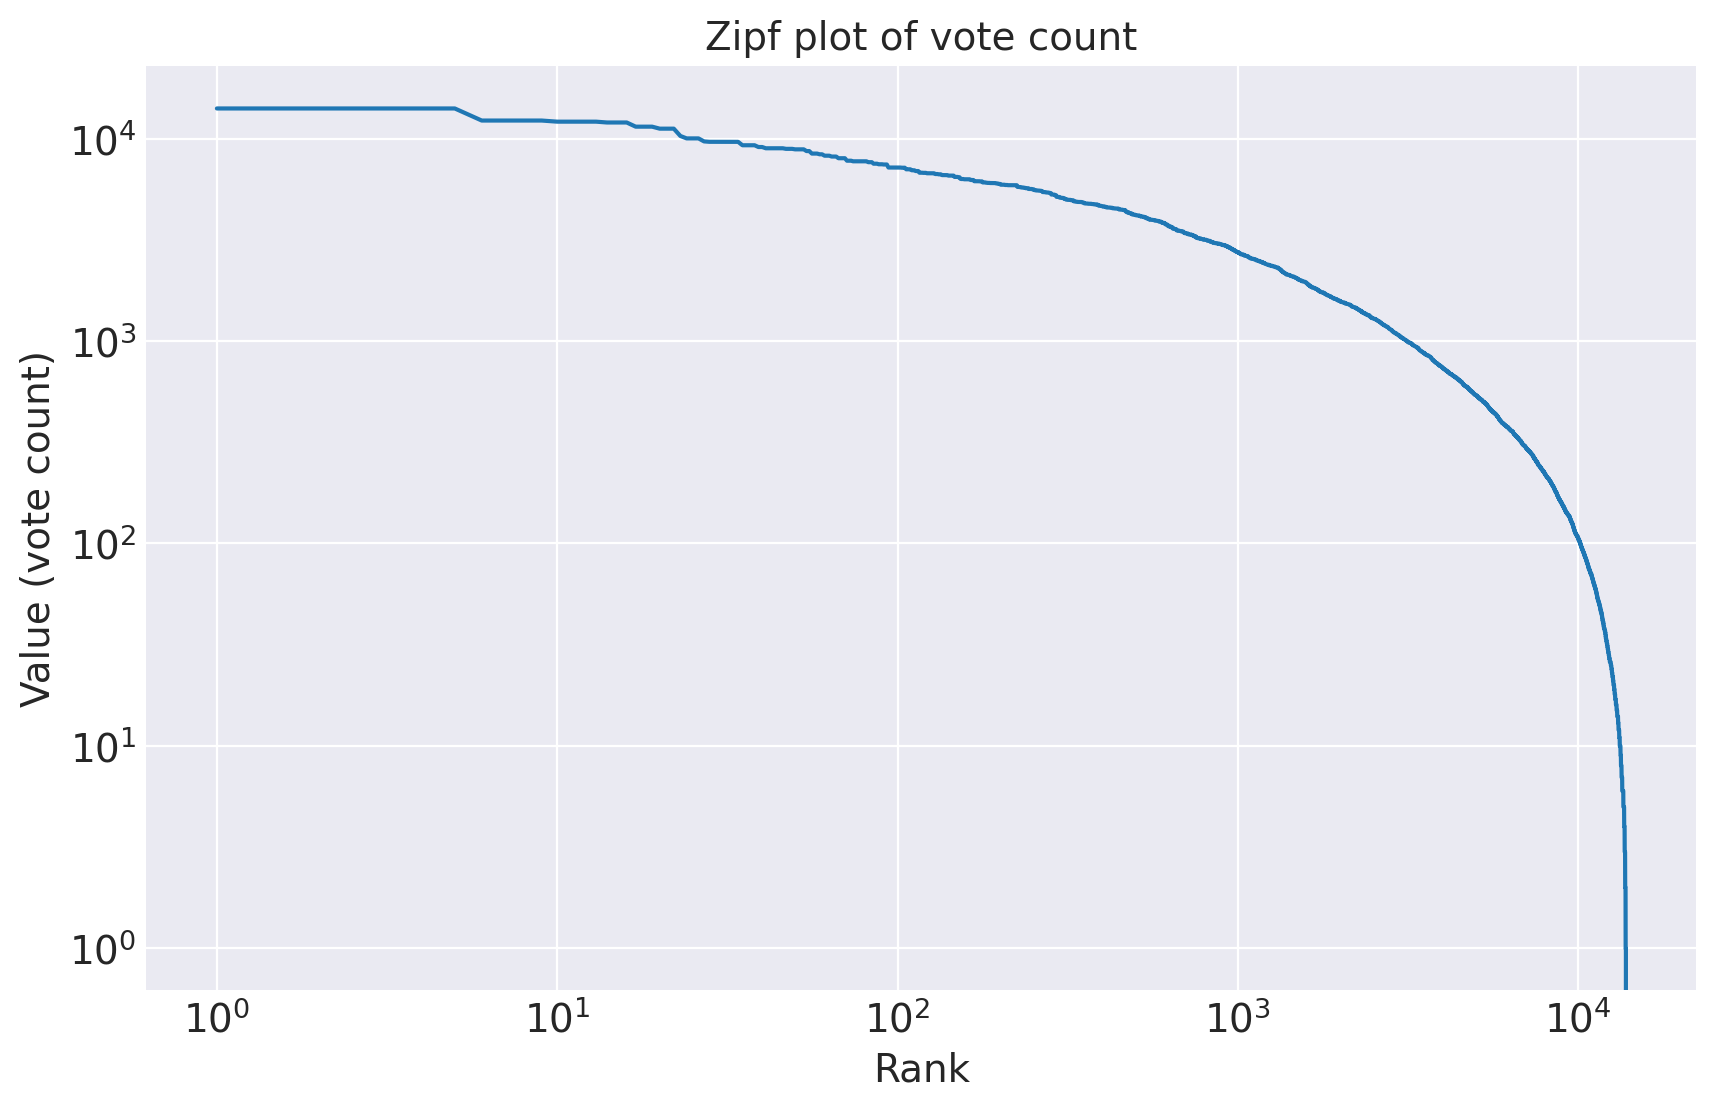

In [177]:
y = data['vote_count'].sort_values(ascending=False)
x = [rank for rank in range(1,len(y)+1)]

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x, y)
ax.set(
    title="Zipf plot of vote count",
    xlabel="Rank",
    ylabel="Value (vote count)"
)
ax.loglog()

At last, we will create a new column in our dataframe, containing the logarithm of ``vote_counts`` and create an equiwidth histogram with 100 bins. 

/tmp/ipykernel_277587/789168468.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['log_votes'] = np.log(data['vote_count']+1) # +1 to escape inf


[Text(0.5, 1.0, 'Logarithmic vote count histogram with 100 bins')]

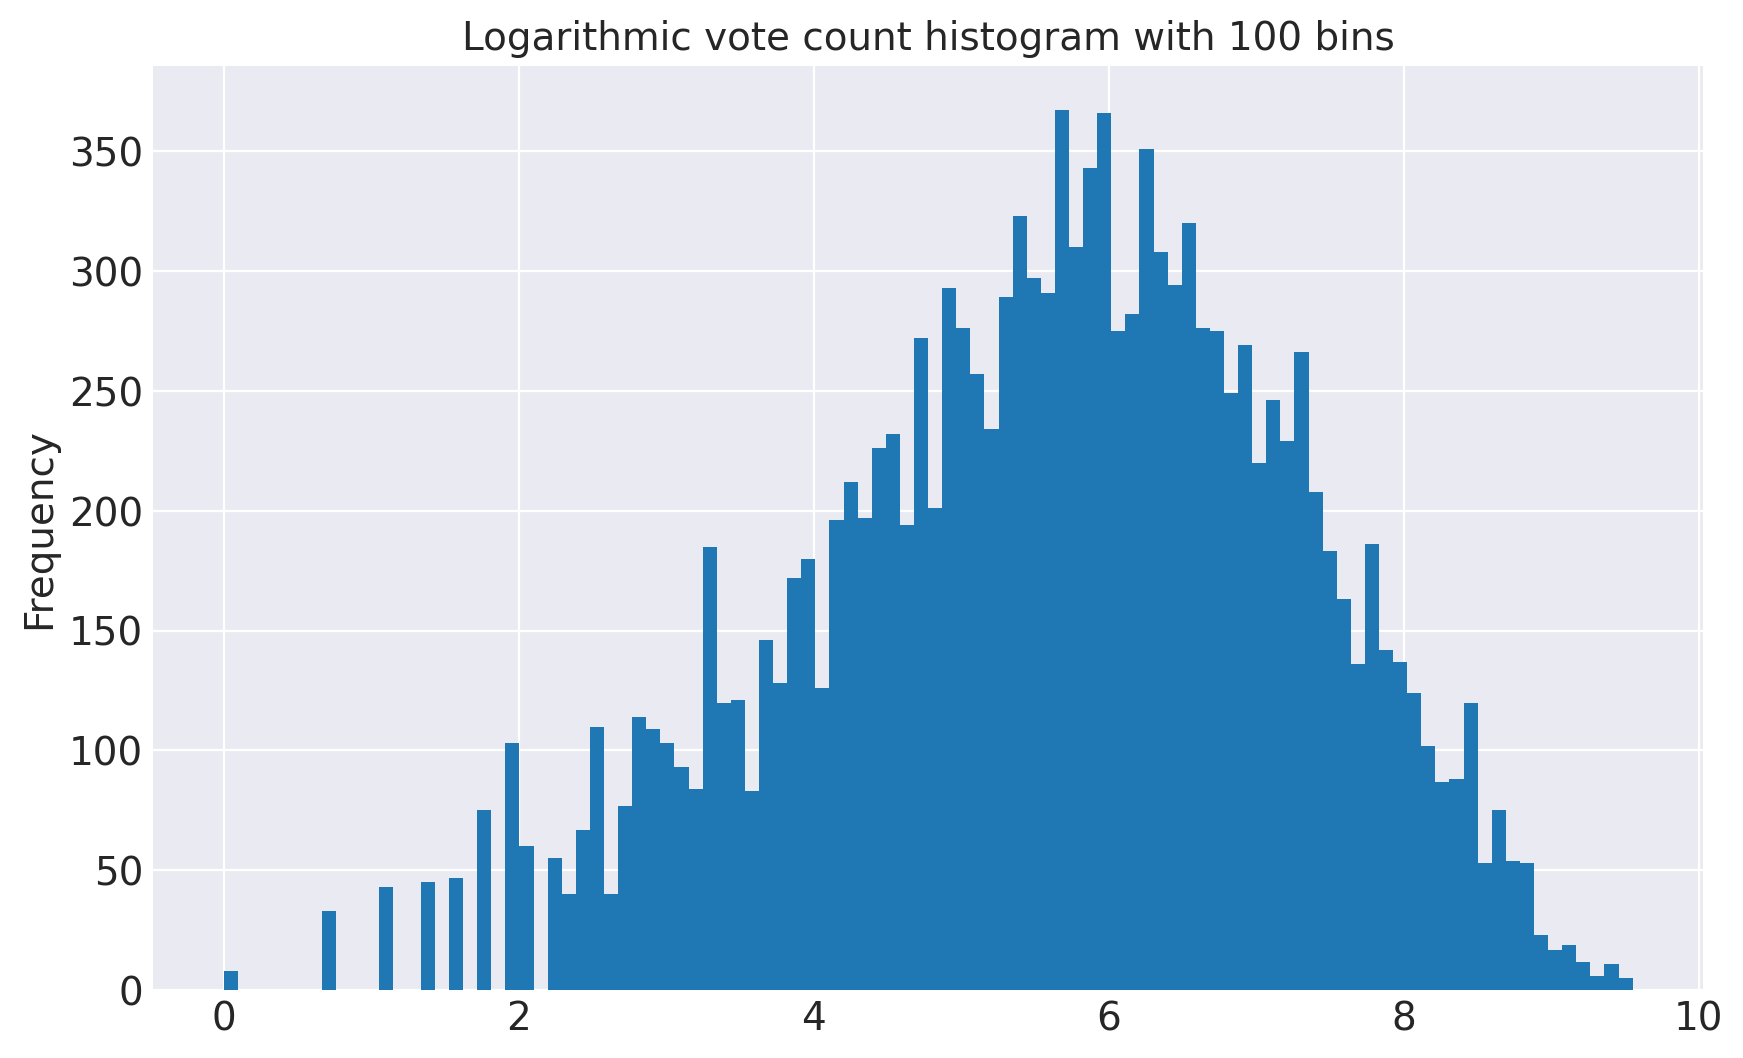

In [173]:
import numpy as np

data['log_votes'] = np.log(data['vote_count']+1) # +1 to escape inf

fig, ax = plt.subplots(figsize=(10,6))
data['log_votes'].plot(kind='hist', bins=100, ax=ax)
ax.set(
    title="Logarithmic vote count histogram with 100 bins",
)

From the above plots, our distribution seems to follow an exponential distribution or power law distribution, where when we we represent the vote count as a logarithm of the original value, it seems to follow a normal distribution. 

## Step 3 - Correlation between duration and vote_average, budget, revenue

We will now move into some hypethesis testing. We will examine the hypothesis:

> Movies with longer duration have bigger budgets but are less popular (smaller vote_average, revenue) 

We will once again filter our dataset and we will keep rows where:
- duration > 30
- vote_count > 10
- budget > 20000
- revenue > 20000

In [26]:
corr_data = data[
    (data['duration'] > 30) & (data['vote_count'] > 10) & (data['budget'] > 20000) & (data['revenue'] > 20000)
]

print(f'Shape of dataframe: {corr_data.shape}')

Shape of dataframe: (4993, 10)


/tmp/ipykernel_277587/1754207303.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_data['budget_millions'] = corr_data['budget']/1_000_000
/tmp/ipykernel_277587/1754207303.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_data['revenue_millions'] = corr_data['revenue']/1_000_000


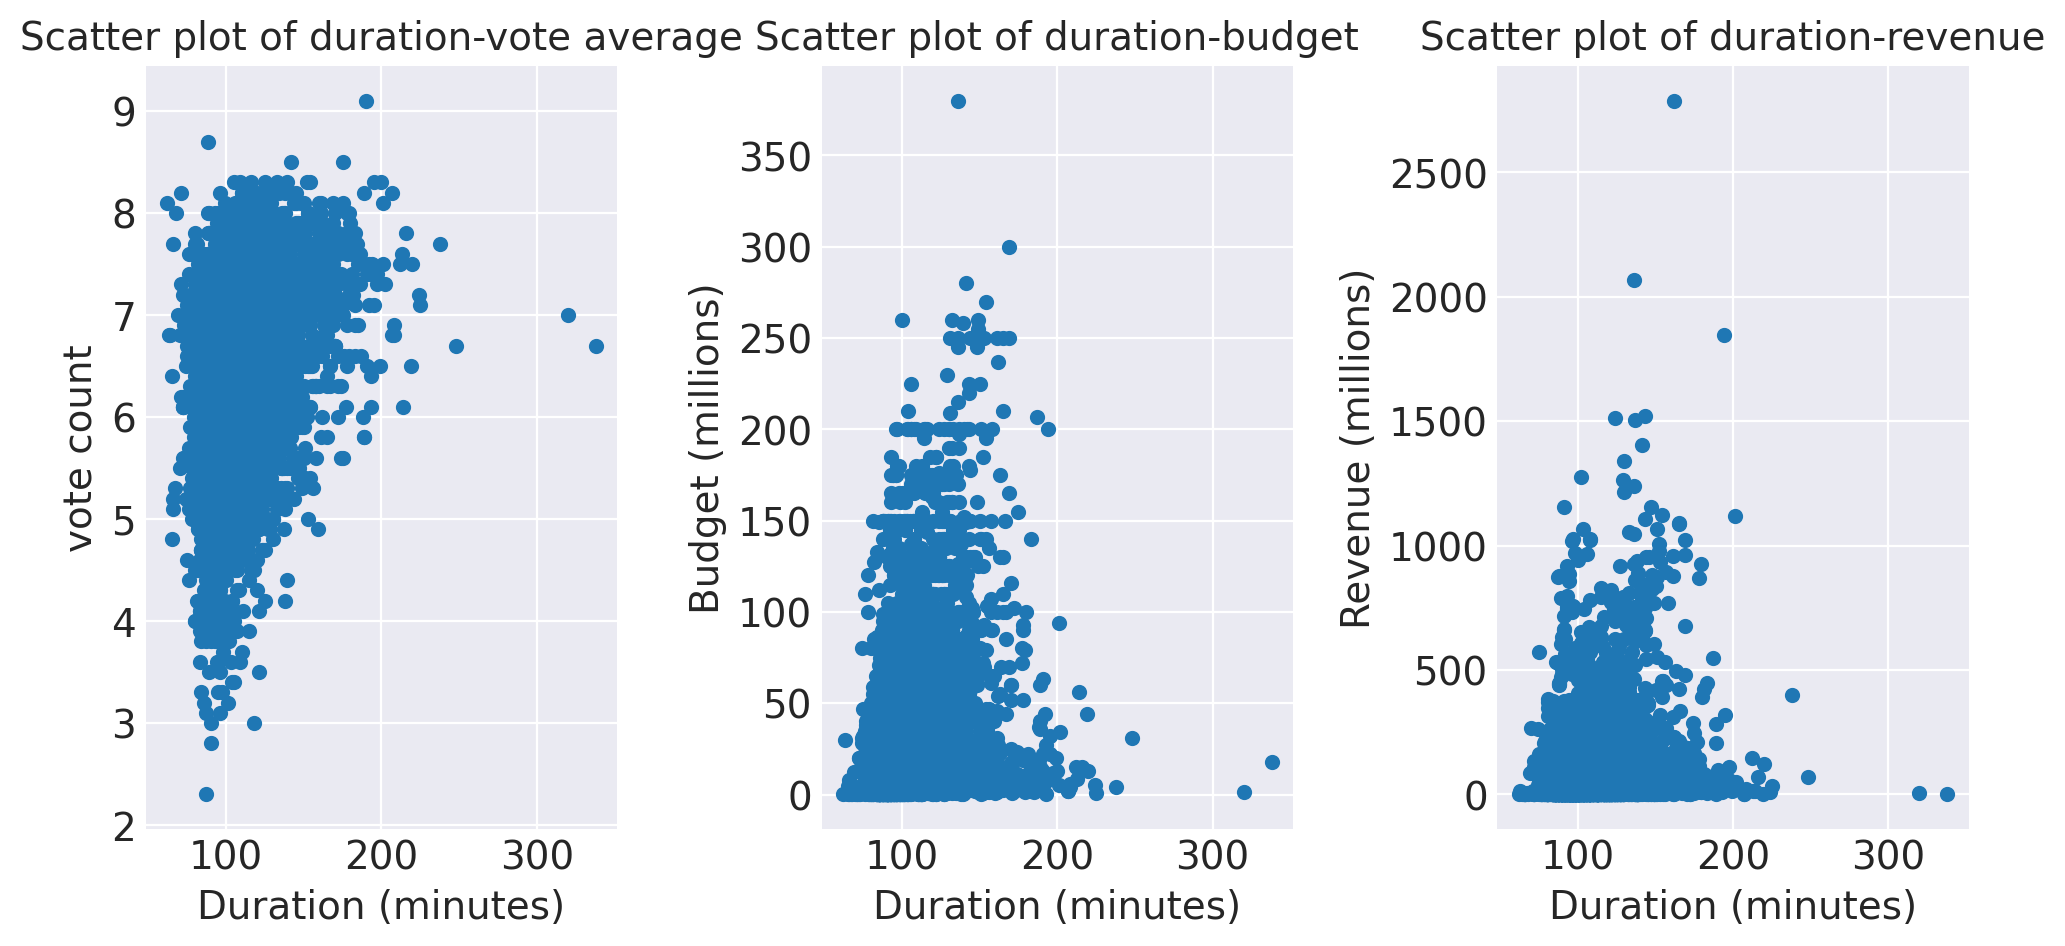

In [27]:
corr_data['budget_millions'] = corr_data['budget']/1_000_000
corr_data['revenue_millions'] = corr_data['revenue']/1_000_000

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10,5))
corr_data.plot(kind='scatter', x='duration', y='vote_average', ax=axs[0])
axs[0].set(
    title="Scatter plot of duration-vote average",
    xlabel="Duration (minutes)",
    ylabel="vote count"
)
corr_data.plot(kind='scatter', x='duration', y='budget_millions', ax=axs[1])
axs[1].set(
    title="Scatter plot of duration-budget",
    xlabel="Duration (minutes)",
    ylabel="Budget (millions)"
)
corr_data.plot(kind='scatter', x='duration', y='revenue_millions', ax=axs[2])
axs[2].set(
    title="Scatter plot of duration-revenue",
    xlabel="Duration (minutes)",
    ylabel="Revenue (millions)"
)
fig.tight_layout(pad=1.2)

From the produced plots, we see that ``vote_count``, ``budget`` and ``revenue`` are all correlated with duration, we will now see how much they correlate using the ``Pearson Correlation Coefficient``.

In [28]:
from scipy.stats import pearsonr

print(pearsonr(corr_data['duration'], corr_data['vote_average']))
print(pearsonr(corr_data['duration'], corr_data['budget_millions']))
print(pearsonr(corr_data['duration'], corr_data['revenue_millions']))

PearsonRResult(statistic=np.float64(0.3579144055735308), pvalue=np.float64(8.50484326310445e-151))
PearsonRResult(statistic=np.float64(0.19292592205198084), pvalue=np.float64(4.534481099570244e-43))
PearsonRResult(statistic=np.float64(0.1928955730773385), pvalue=np.float64(4.674939925172876e-43))


With significance level $\alpha=0.05$ we can reject the null hypothesis of the Pearson Coefficient Test for all of the tests. 
In all three tests, we get a small positive effect size.

## Step 4 - Older movies better that newer?

**Hypothesis**: Many support that the quality of movies is getting worse by the time and better movies are better.

We will use the ``release_date`` field to take the decade of the release of films and the ``vote_average`` to take the quality of the film.

We will also ignore movies with less that 10 votes and decades with less that 50 movies.

Use <u>``seaborn.lineplot``</u> and produce a chart with the mean quality of the movies per decade and the 95% confidence interval.
State observations.

In [29]:
datafr = data[['release_date', 'vote_average', 'vote_count']]
datafr['release_year'] = (np.floor(datafr.release_date.dt.year/10)*10).astype(int)
datafr

/tmp/ipykernel_277587/3121481073.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datafr['release_year'] = (np.floor(datafr.release_date.dt.year/10)*10).astype(int)


,release_date,vote_average,vote_count,release_year
0,1995-10-30,7.7,5415,1990
1,1995-12-15,6.9,2413,1990
3,1995-12-22,6.1,34,1990
5,1995-12-15,7.7,1886,1990
8,1995-12-22,5.5,174,1990
...,...,...,...,...
45167,2017-08-03,7.4,181,2010
45250,2007-06-14,6.9,25,2000
45409,2006-11-23,5.8,6,2000
45412,2010-09-30,4.0,3,2010


Keep only the movies with at least 10 vote counts.

In [30]:
datafr = datafr[datafr['vote_count'] > 10]
datafr.shape

(5087, 4)

Keep only decades with more than 50 movies per decade.

In [31]:
datafr_groups = datafr.groupby('release_year').filter(lambda x: len(x) > 50)
datafr_groups.shape, datafr_groups.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5009 entries, 0 to 45250
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   release_date  5009 non-null   datetime64[ns]
 1   vote_average  5009 non-null   float64       
 2   vote_count    5009 non-null   int64         
 3   release_year  5009 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 195.7 KB


((5009, 4), None)

In [32]:
datafr_groups['release_year'].value_counts()

release_year
2000    1685
2010    1569
1990     885
1980     496
1970     178
1960     127
1950      69
Name: count, dtype: int64

We now take the mean ``vote_average`` of the movies of each decade.

[Text(0.5, 1.0, 'Vote average by decade')]

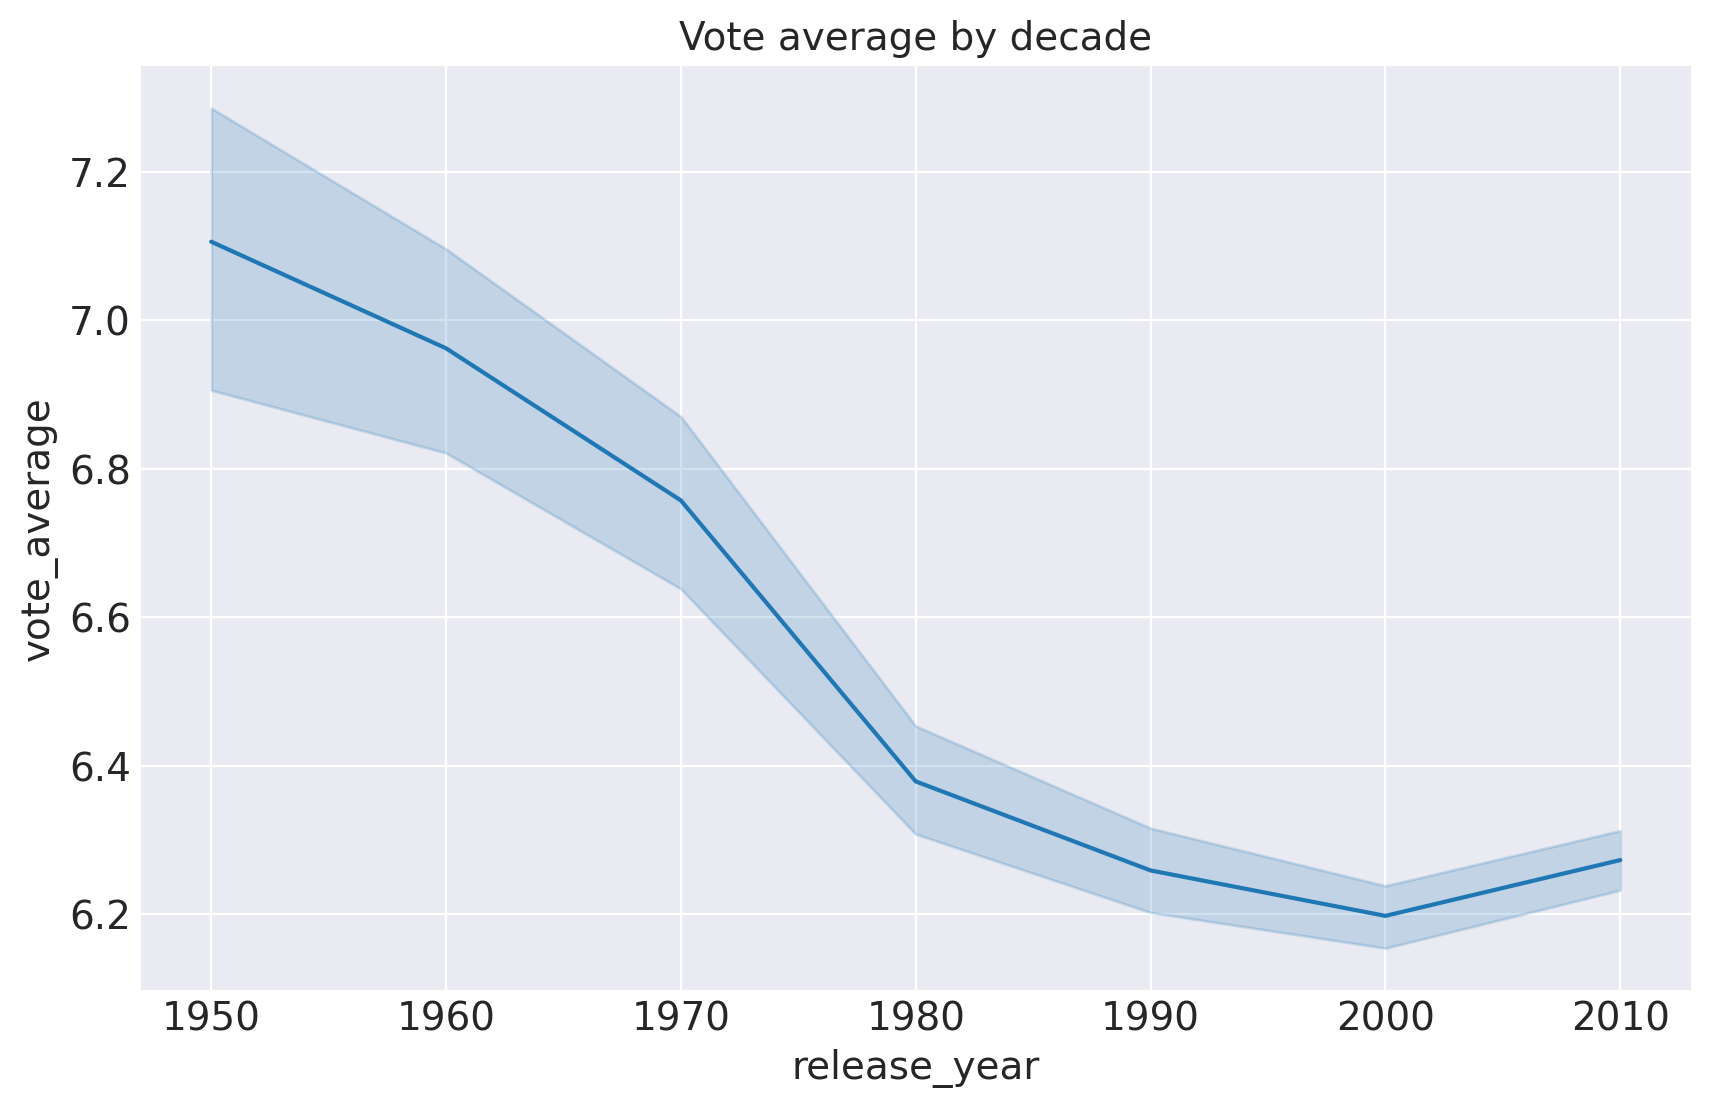

In [34]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(
    data=datafr_groups,
    x='release_year',
    y='vote_average',
    errorbar=('ci', 95),
    ax=ax
)
ax.set(
    title="Vote average by decade"
)

We clearly see that the ``vote_average`` is declining by each decade, but we also see that the 95% confidence interval has a wider range in the earlier decades, implying that we are more uncertain of the location of the mean in different samples.

## Bonus - Older movies have fewer data that newer

We will first see how any movies are where released by each decade.

[Text(0.5, 1.0, 'Movies released by decade'),
 Text(0.5, 0, 'Decade'),
 Text(0, 0.5, 'Movies released')]

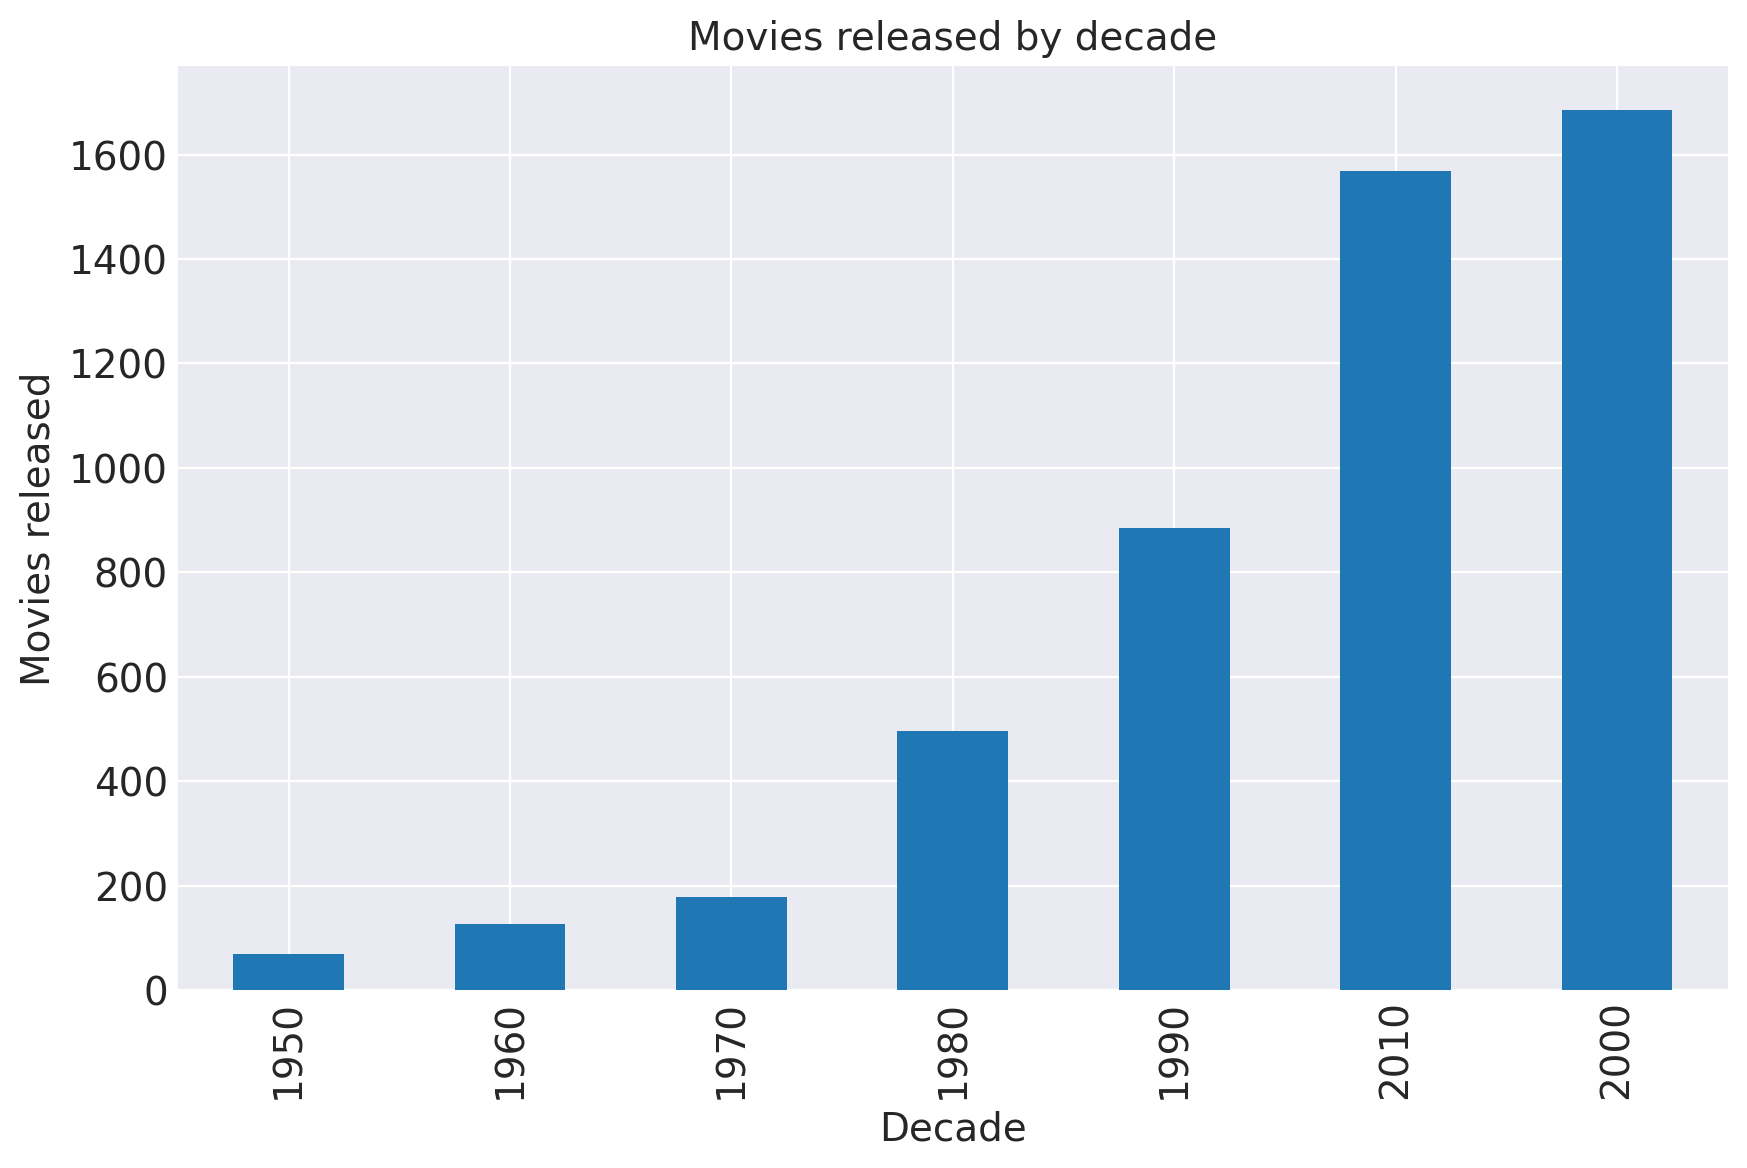

In [244]:
fig, ax = plt.subplots(figsize=(10,6))
datafr_groups.release_year.value_counts().sort_values(by=).plot(
    kind='bar',
    ax=ax,
)
ax.set(
    title="Movies released by decade",
    xlabel="Decade",
    ylabel='Movies released'
)

We see that movies released from 1950 up untill the 1990's decade, are approximately the same number as movies released in the 2000s and 2010s. We will group them into two groups, compare the means and perhaps running a t-test. 

In [259]:
old_movies = datafr_groups[datafr_groups.release_year <= 1990]
new_movies = datafr_groups[datafr_groups.release_year >= 2000]
print(f'Old movies mean vote average: {old_movies.vote_average.mean()}, std: {old_movies.vote_average.std()}, count: {old_movies.shape[0]}')
print(f'New movies mean vote average: {new_movies.vote_average.mean()}, std: {new_movies.vote_average.std()}, count: {new_movies.shape[0]}')

Old movies mean vote average: 6.4275213675213685, std: 0.8992016977537833, count: 1755
New movies mean vote average: 6.233927473878304, std: 0.8204567131935451, count: 3254


In [260]:
new_movies_sampled = new_movies.sample(1755)

print(f'Old movies mean vote average: {old_movies.vote_average.mean()}, std: {old_movies.vote_average.std()}')
print(f'New movies mean vote average: {new_movies_sampled.vote_average.mean()}, std: {new_movies_sampled.vote_average.std()}')

Old movies mean vote average: 6.4275213675213685, std: 0.8992016977537833
New movies mean vote average: 6.222792022792023, std: 0.8186913936960192


In [261]:
from scipy.stats import ttest_ind

In [262]:
ttest_ind(old_movies['vote_average'], new_movies_sampled['vote_average'])

TtestResult(statistic=np.float64(7.0527924424856705), pvalue=np.float64(2.1029537310649446e-12), df=np.float64(3508.0))

We see that with significance level $a=0.05$ we can reject our null hypothesis, hence the difference in the means of the two groups of movies (old and new) is significant, meaning that older generations indeed voted differently on average, and they voted higher than the current generation, and someone could tell that because of that, movies have indeed gone worse during recent years. Or people have become more selective and judgemental, who knows really.

## Step 5 - Correlation between movie director sex and genre

To examine whether there is a correlation between the movie director and his sex, we will perform a $\chi^2$ Independence Test. The test's Null Hypothesis states that there is no association between the observed frequency count and the expected frequency count, which we obtain through computing marginal probabilities and produce it under the assumption that our variables are independent.

In our case, our Null Hypothesis $H_0$ states that:

$H_0$="There is no association between the movie director's sex and the movie's genre"

We need to make some processing into our data to accomplish our objective. We will do the following:
- Extract the ``genres`` of the movies
- Load a second dataframe named ``credits.csv``, keep the Directors and their sex.

In [38]:
data

,id,title,vote_count,duration,vote_average,revenue,budget,release_date,genres,log_votes
0,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,"[Animation, Comedy, Family]",8.597113
1,8844,Jumanji,2413,104,6.9,262797249,65000000,1995-12-15,"[Adventure, Fantasy, Family]",7.789040
3,31357,Waiting to Exhale,34,127,6.1,81452156,16000000,1995-12-22,"[Comedy, Drama, Romance]",3.555348
5,949,Heat,1886,170,7.7,187436818,60000000,1995-12-15,"[Action, Crime, Drama, Thriller]",7.542744
8,9091,Sudden Death,174,106,5.5,64350171,35000000,1995-12-22,"[Action, Adventure, Thriller]",5.164786
...,...,...,...,...,...,...,...,...,...,...
45167,395834,Wind River,181,111,7.4,184770205,11000000,2017-08-03,"[Action, Crime, Mystery, Thriller]",5.204007
45250,24049,Sivaji: The Boss,25,185,6.9,19000000,12000000,2007-06-14,"[Action, Comedy, Drama]",3.258097
45409,62757,Savages,6,100,5.8,1328612,800000,2006-11-23,"[Comedy, Drama]",1.945910
45412,63281,Pro Lyuboff,3,107,4.0,1268793,2000000,2010-09-30,"[Romance, Drama]",1.386294


We start of by converting our entries into the ``genres`` column of our dataframe, into lists containing genre names.

In [280]:
## Ignore the error that is on display at the .html, run it twice accidentally.

import ast

data['genres'] = data['genres'].apply(ast.literal_eval)
data['genres'] = data['genres'].apply(lambda genre_list: [dictionary.get('name') for dictionary in genre_list])
print(data.genres)

ValueError: malformed node or string on line 1: <ast.Name object at 0x79201f5abb10>

We will now expand our entries, by expanding our genres into multiple enties, for example, a row with an entry containing a list with 3 genres in the ``genres`` column, will now appear three times into our dataframe.

In [39]:
data = data.explode(column='genres')
data

,id,title,vote_count,duration,vote_average,revenue,budget,release_date,genres,log_votes
0,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Animation,8.597113
0,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Comedy,8.597113
0,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Family,8.597113
1,8844,Jumanji,2413,104,6.9,262797249,65000000,1995-12-15,Adventure,7.789040
1,8844,Jumanji,2413,104,6.9,262797249,65000000,1995-12-15,Fantasy,7.789040
...,...,...,...,...,...,...,...,...,...,...
45412,63281,Pro Lyuboff,3,107,4.0,1268793,2000000,2010-09-30,Drama,1.386294
45422,63898,Antidur,1,91,1.0,1413000,5000000,2007-09-06,Action,0.693147
45422,63898,Antidur,1,91,1.0,1413000,5000000,2007-09-06,Comedy,0.693147
45422,63898,Antidur,1,91,1.0,1413000,5000000,2007-09-06,Crime,0.693147


We will now only keep genres present on at least 100 movies.

In [41]:
data['genres'].value_counts()

genres
Drama              2579
Comedy             1845
Thriller           1502
Action             1413
Romance            1011
Adventure           959
Crime               859
Science Fiction     633
Horror              586
Family              532
Fantasy             511
Mystery             443
Animation           293
History             235
War                 203
Music               192
Western              89
Documentary          59
Foreign              32
TV Movie              1
Name: count, dtype: int64

In [42]:
data = data[~data['genres'].isin(['Western', 'Documentary', 'Foreign', 'TV Movie'])]
data.genres.value_counts()

genres
Drama              2579
Comedy             1845
Thriller           1502
Action             1413
Romance            1011
Adventure           959
Crime               859
Science Fiction     633
Horror              586
Family              532
Fantasy             511
Mystery             443
Animation           293
History             235
War                 203
Music               192
Name: count, dtype: int64

Loading the ``credits.csv`` file, in order to extract for each movie the director ('job': `Director`) and the sex of the director.

In [43]:
credits = pd.read_csv('data/credits.csv')
credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [44]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


We will apply the same data transformation we applied for the ``genres`` column, but we will keep different values.

In [45]:
import ast

credits['crew'] = credits['crew'].apply(ast.literal_eval)

#see keys of each category
print(credits.loc[0, 'crew'][0].keys())

dict_keys(['credit_id', 'department', 'gender', 'id', 'job', 'name', 'profile_path'])


In [46]:
credits_df = credits[['id', 'crew']].copy()
credits_df.head()

,id,crew
0,862,"[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,8844,"[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,15602,"[{'credit_id': '52fe466a9251416c75077a89', 'de..."
3,31357,"[{'credit_id': '52fe44779251416c91011acb', 'de..."
4,11862,"[{'credit_id': '52fe44959251416c75039ed7', 'de..."


In [47]:
credits_df['crew'] = credits_df['crew'].apply(
    lambda row: [[record['job'], record['gender']] for record in row
    if ((record['job'] == 'Director') and ((record['gender'] == 1) or (record['gender'] == 2)))]
)
credits_df

,id,crew
0,862,"[[Director, 2]]"
1,8844,"[[Director, 2]]"
2,15602,"[[Director, 2]]"
3,31357,"[[Director, 2]]"
4,11862,"[[Director, 2]]"
...,...,...
45471,439050,[]
45472,111109,[]
45473,67758,"[[Director, 2]]"
45474,227506,[]


In [48]:
credits_df = credits_df.explode(column='crew')
credits_df

,id,crew
0,862,"[Director, 2]"
1,8844,"[Director, 2]"
2,15602,"[Director, 2]"
3,31357,"[Director, 2]"
4,11862,"[Director, 2]"
...,...,...
45471,439050,NaN
45472,111109,NaN
45473,67758,"[Director, 2]"
45474,227506,NaN


In [49]:
credits_df.isnull().sum()

id          0
crew    17541
dtype: int64

In [50]:
credits_df.dropna()

,id,crew
0,862,"[Director, 2]"
1,8844,"[Director, 2]"
2,15602,"[Director, 2]"
3,31357,"[Director, 2]"
4,11862,"[Director, 2]"
...,...,...
45467,390959,"[Director, 2]"
45468,289923,"[Director, 2]"
45469,222848,"[Director, 2]"
45470,30840,"[Director, 2]"


Forgot to turn ``id`` of the ``metadata.csv`` into an integer, needed for the joining of the two dataframes, doing it now.

In [51]:
data['id'] = data['id'].astype('int')

/tmp/ipykernel_277587/705120429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['id'] = data['id'].astype('int')


Let's now merge the dataframes ``credits_df`` and ``data`` by performing an inner join on the key ``id``.

In [52]:
joined_df = data.merge(credits_df, how='inner', on='id')
joined_df = joined_df.dropna()

In [53]:
joined_df[['job', 'gender']] = joined_df['crew'].to_list()
joined_df['gender'] = joined_df['gender'].map({1: 'female', 2: 'male'})
joined_df

,id,title,vote_count,duration,vote_average,revenue,budget,release_date,genres,log_votes,crew,job,gender
0,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Animation,8.597113,"[Director, 2]",Director,male
1,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Comedy,8.597113,"[Director, 2]",Director,male
2,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Family,8.597113,"[Director, 2]",Director,male
3,8844,Jumanji,2413,104,6.9,262797249,65000000,1995-12-15,Adventure,7.789040,"[Director, 2]",Director,male
4,8844,Jumanji,2413,104,6.9,262797249,65000000,1995-12-15,Fantasy,7.789040,"[Director, 2]",Director,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14594,24049,Sivaji: The Boss,25,185,6.9,19000000,12000000,2007-06-14,Action,3.258097,"[Director, 2]",Director,male
14595,24049,Sivaji: The Boss,25,185,6.9,19000000,12000000,2007-06-14,Comedy,3.258097,"[Director, 2]",Director,male
14596,24049,Sivaji: The Boss,25,185,6.9,19000000,12000000,2007-06-14,Drama,3.258097,"[Director, 2]",Director,male
14599,63281,Pro Lyuboff,3,107,4.0,1268793,2000000,2010-09-30,Romance,1.386294,"[Director, 1]",Director,female


Now we will calculate the **Observed Contigency Matrix** for the variables ``genres`` and ``gender`` and plot it as a heatmap.

In [233]:
cont_table['male'].index

Index(['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama',
       'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance',
       'Science Fiction', 'Thriller', 'War'],
      dtype='object', name='genres')

<Axes: xlabel='gender', ylabel='genres'>

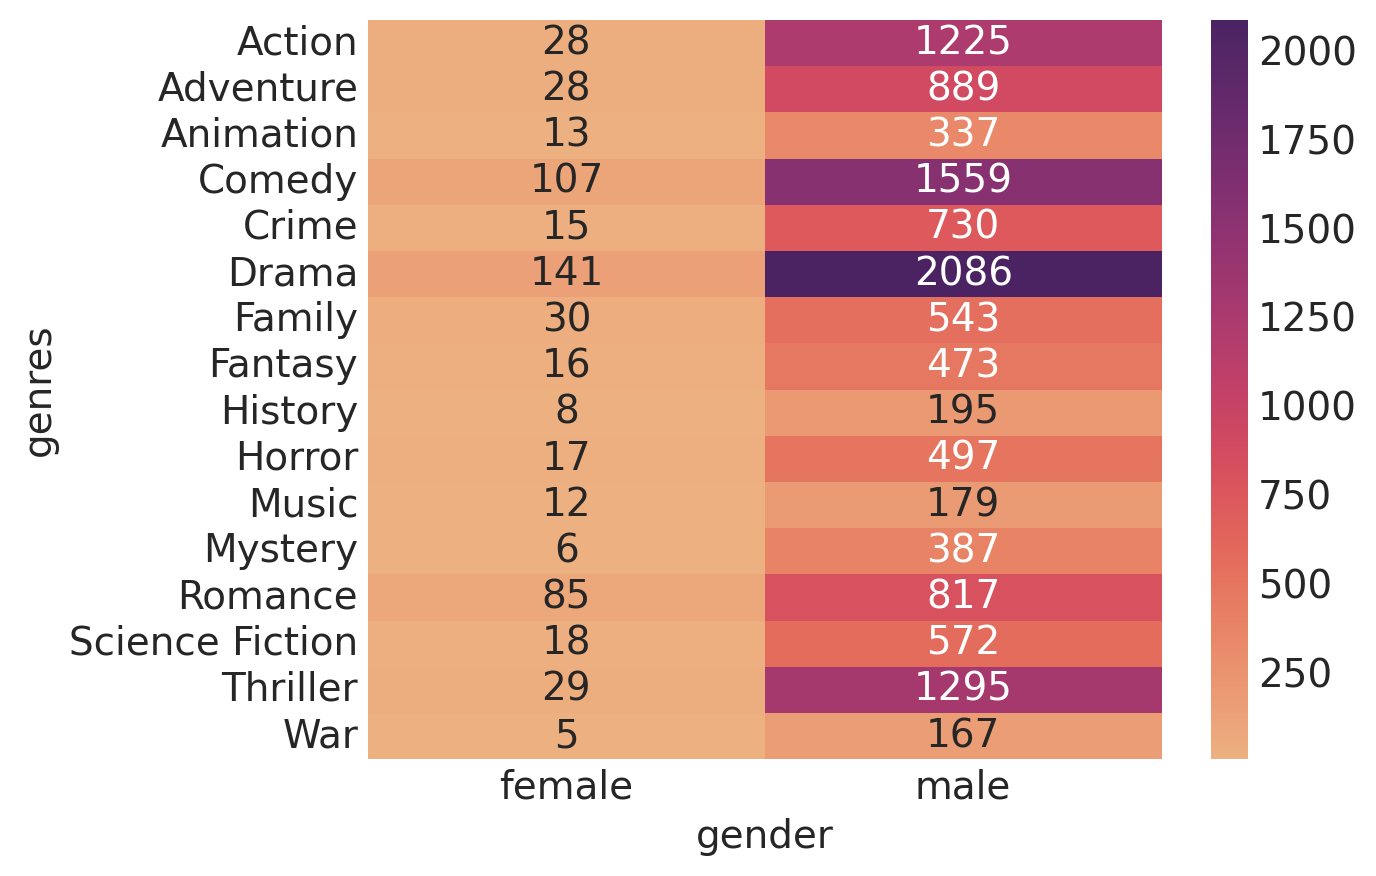

In [224]:
cont_table = pd.crosstab(joined_df['genres'],
                        joined_df['gender'])

sns.heatmap(cont_table, annot=True, cmap="flare", fmt='g')

As we see, female directors in all categories are significantly less that male directors, because of the underrepresantation of women directors. We will now proceed to perform a $\chi^2$ test, using the ``chi2_contigency`` from ``scipy.stats``, in order to obtain also the **Expected Contigency Matrix** of the variables ``gender`` and ``genres``.

In [226]:
from scipy.stats import chi2_contingency

<Axes: >

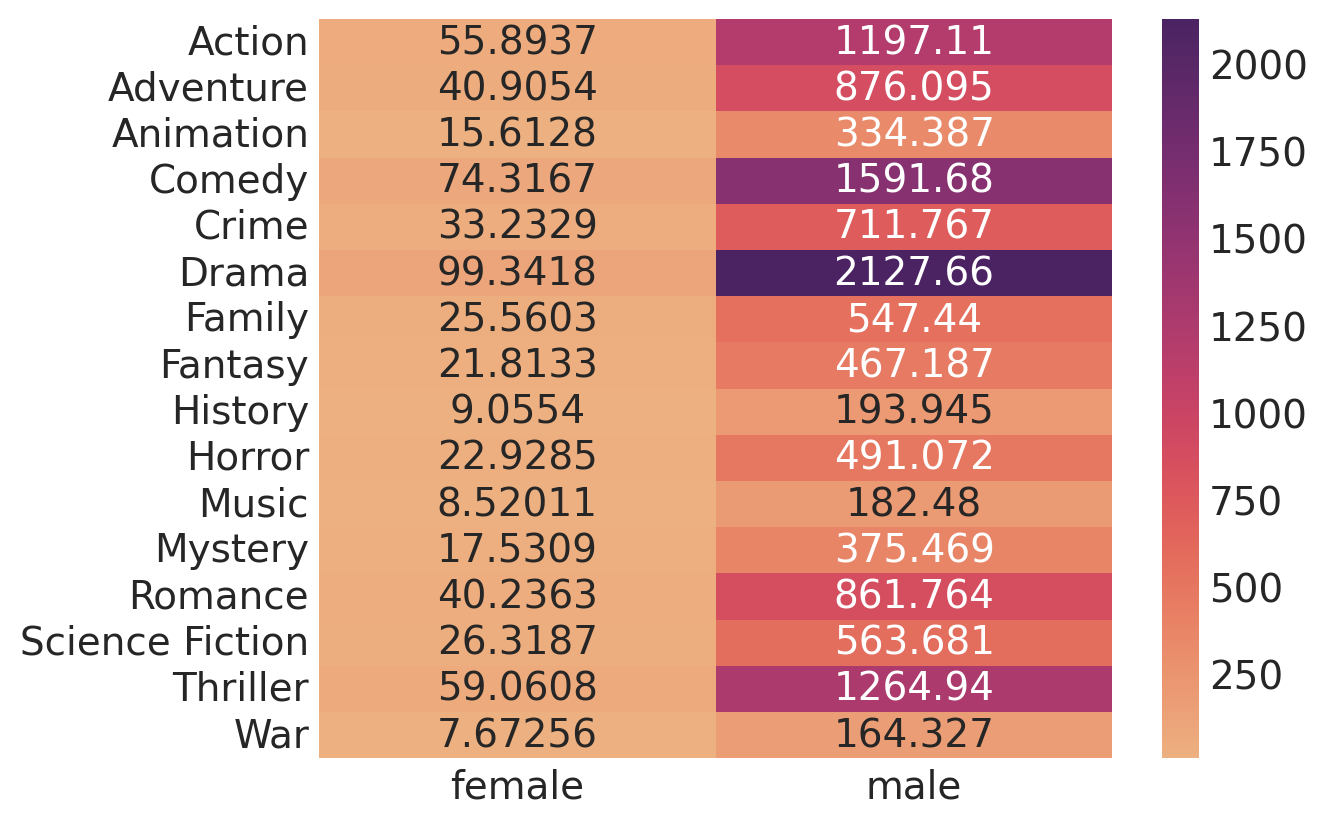

In [235]:
chi2_obj = chi2_contingency(cont_table)
statistic = chi2_obj.statistic
pv = chi2_obj.pvalue
indep_cont = chi2_obj.expected_freq

yticklabels = cont_table['male'].index
xticklabels = ['female', 'male']

sns.heatmap(indep_cont, annot=True, cmap="flare", fmt="g", xticklabels=xticklabels, yticklabels=yticklabels)

In [228]:
chi2_obj

Chi2ContingencyResult(statistic=np.float64(148.54441524937545), pvalue=np.float64(4.692538546671805e-24), dof=15, expected_freq=array([[  55.89367655, 1197.10632345],
       [  40.90542809,  876.09457191],
       [  15.61275881,  334.38724119],
       [  74.31673195, 1591.68326805],
       [  33.23287233,  711.76712767],
       [  99.34175394, 2127.65824606],
       [  25.56031657,  547.43968343],
       [  21.81325446,  467.18674554],
       [   9.05540011,  193.94459989],
       [  22.92845151,  491.07154849],
       [   8.52010552,  182.47989448],
       [  17.53089775,  375.46910225],
       [  40.23630986,  861.76369014],
       [  26.31865057,  563.68134943],
       [  59.0608362 , 1264.9391638 ],
       [   7.67255576,  164.32744424]]))

With significance value $a=0.05$, a p-value much smaller than our significance level and an effect size of $\chi^2=148.54$, we can reject the Null Hypothesis of the $\chi^2$ Independence Test, meaning that the data are not consistent with $H_0$ or there are associations between the movie director's sex the the movie genre.

In [79]:
lift = cont_table / indep_cont
for row in lift:
    print(row)

[0.50095112 1.02330092]
[0.68450573 1.01473063]
[0.83265233 1.00781357]
[1.43978344 0.97946622]
[0.45136032 1.02561635]
[1.41934277 0.98042061]
[1.17369438 0.9918901 ]
[0.73349898 1.01244311]
[0.88345075 1.00544176]
[0.7414369  1.01207248]
[1.40843326 0.98092998]
[0.34225287 1.03071064]
[2.11251977 0.94805572]
[0.68392564 1.01475772]
[0.49101912 1.02376465]
[0.65167334 1.0162636 ]


When you look at the Observed table and the Expected table, if we look the pairs $O(x,y)$ and $E(x,y)$ we can see if there is correlation between the values of the two categories by the following:
- if $O(x,y) >> E(x,y)$ then there if a possitive correlation between the values
- if $O(x,y) << E(x,y)$ then there if a negative correlation between the values
- Otherwise, there is no correlation.

[Text(0.5, 1.0, 'Expected Contigency Table')]

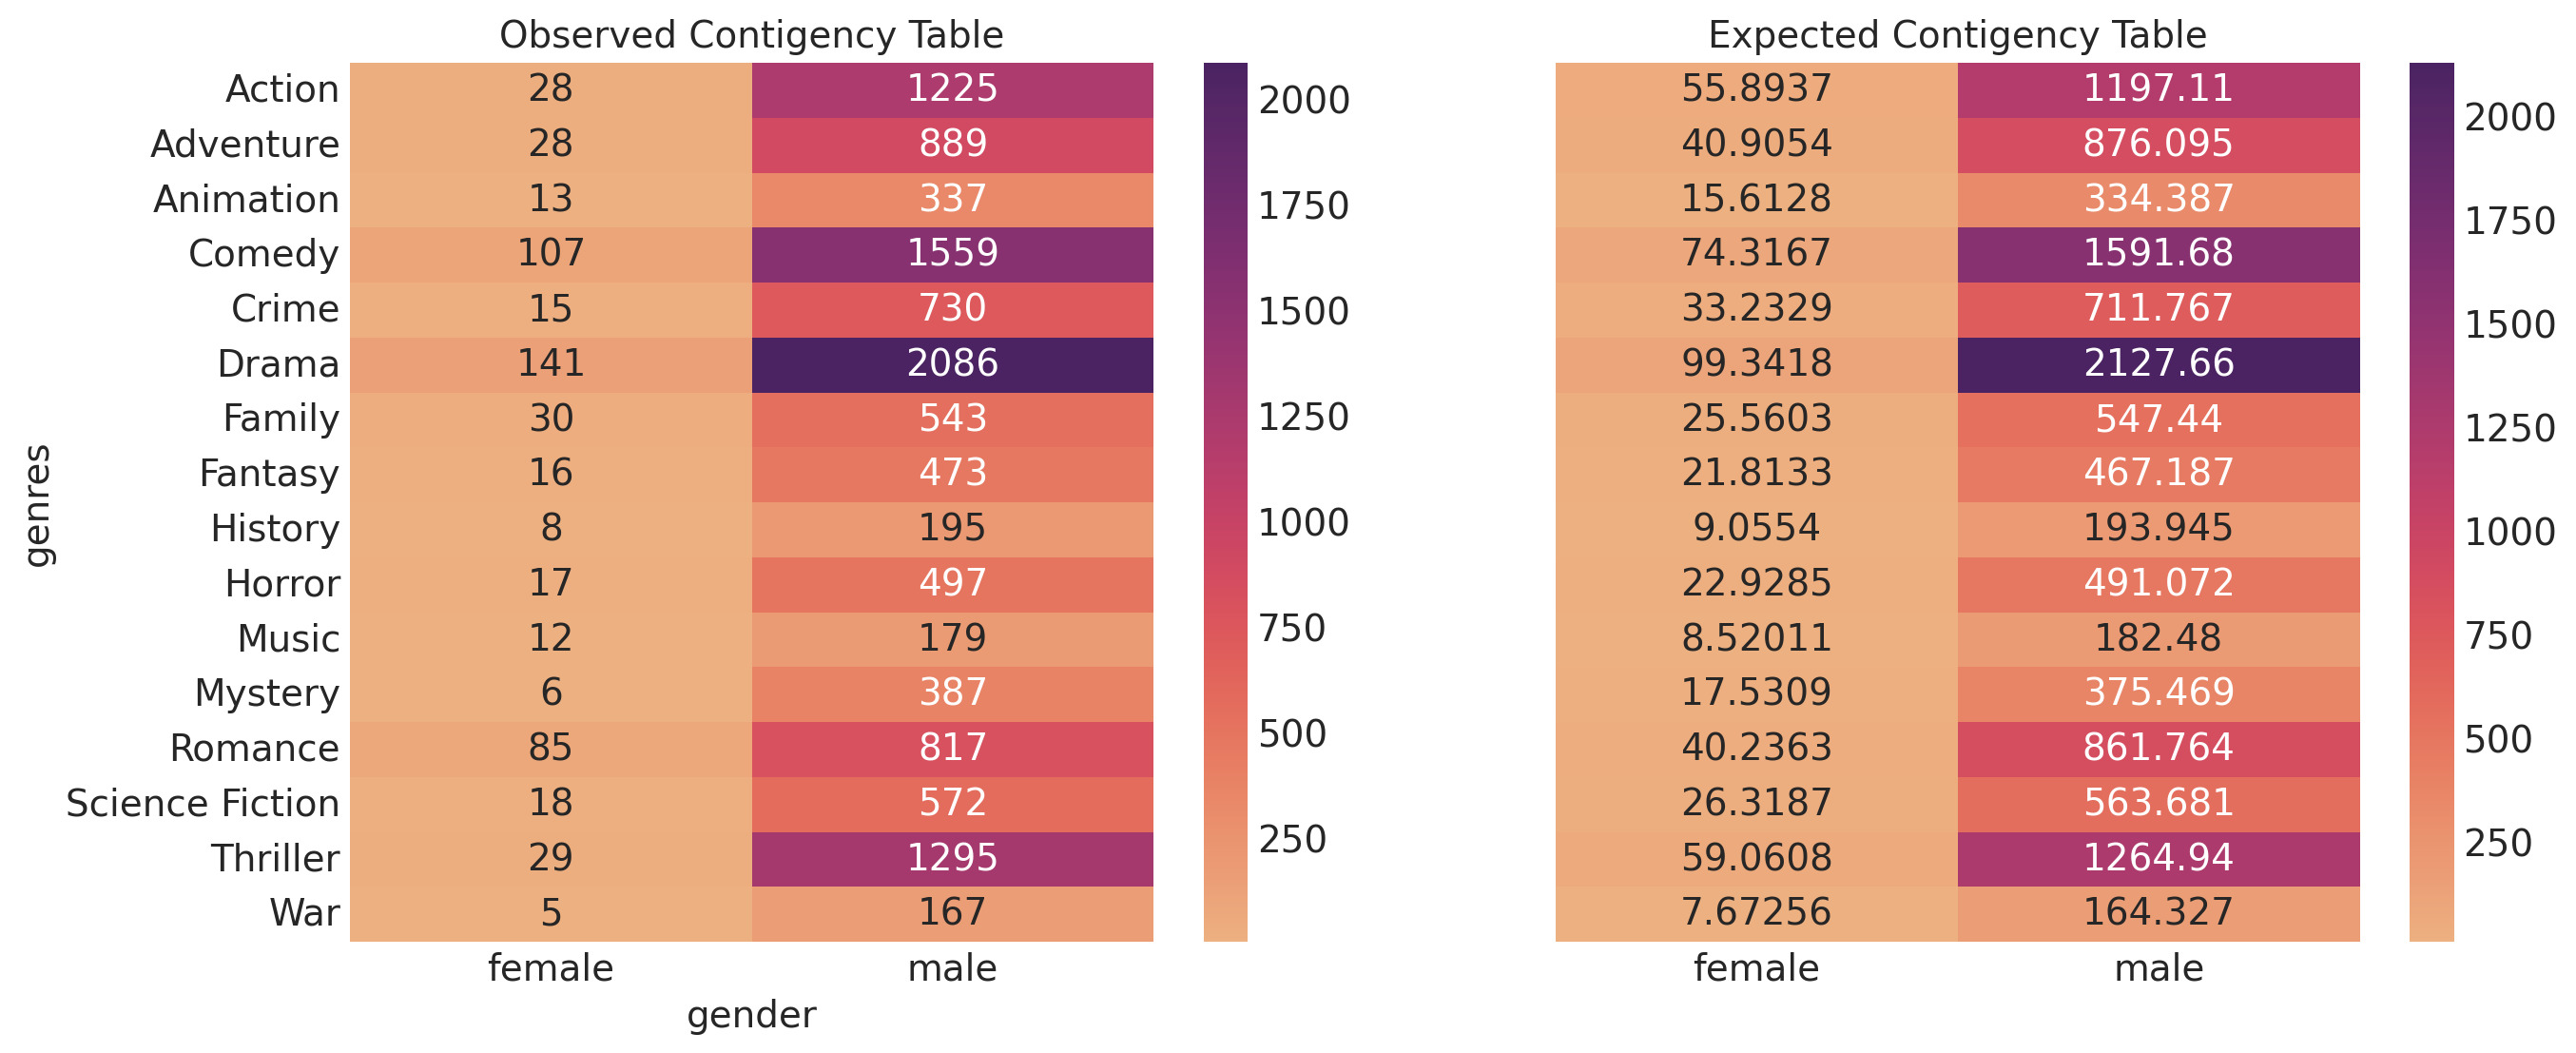

In [243]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
sns.heatmap(cont_table, annot=True, cmap="flare", fmt='g', ax=axs[0])
axs[0].set(title="Observed Contigency Table")
sns.heatmap(indep_cont, annot=True, cmap="flare", fmt="g", xticklabels=xticklabels, yticklabels='', ax=axs[1])
axs[1].set(title="Expected Contigency Table")

We can now clearly see that most correlations occur in the values of females and genres, because $O(x,y)$ and $E(x,y)$. This is also seen above when using the lift, a lift value around one, indicates similar values between $O(x,y)$ and $E(x,y)$, and hence no correlation, where lift sizes bigger than 1 indicate $O(x,y)$ >> $E(x,y)$, hence positive correlation, and lift sizes smaller than 1 indicate $O(x,y)$ << $E(x,y)$, hence negative correlation.

## Step 6 - Statistical difference in mean values of ``revenue``, ``budget`` and ``vote_average`` between genres ``Action`` and ``Drama``

To see if there is statistical difference in the means of ``revenue``, ``budget`` and ``vote_average`` between ``genres`` Action and Drama, we would run a **Student t-test**. The null hypothesis asserts that there is no difference in means between the two groups, while the alternative hypothesis claims that a difference exists.

We would first create barplots and see if we can extract information from them.

In [125]:
req_data = joined_df[joined_df['genres'].isin(['Action', 'Drama'])]
req_data = req_data[['id','revenue', 'budget', 'vote_average', 'genres']]
req_data.head()

,id,revenue,budget,vote_average,genres
7,31357,81452156,16000000,6.1,Drama
9,949,187436818,60000000,7.7,Action
11,949,187436818,60000000,7.7,Drama
13,9091,64350171,35000000,5.5,Action
17,710,352194034,58000000,6.6,Action


In [126]:
def plot_barcharts(data: pd.DataFrame, x: str, y:list[str], titles=list[str]):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10,7))
    sns.barplot(
        data=data, 
        x=x,
        y=y[0],
        estimator='mean',
            ax=axs[0]
    )
    axs[0].set(
        title=titles[0]
    )

    sns.barplot(
        data=data, 
        x=x,
        y=y[1],
        estimator='mean',
        ax=axs[1]
    )

    axs[1].set(
        title=titles[1]
    )

    sns.barplot(
        data=data, 
        x=x,
        y=y[2],
        estimator='mean',
        ax=axs[2]
    )

    axs[2].set(
        title=titles[2]
    )

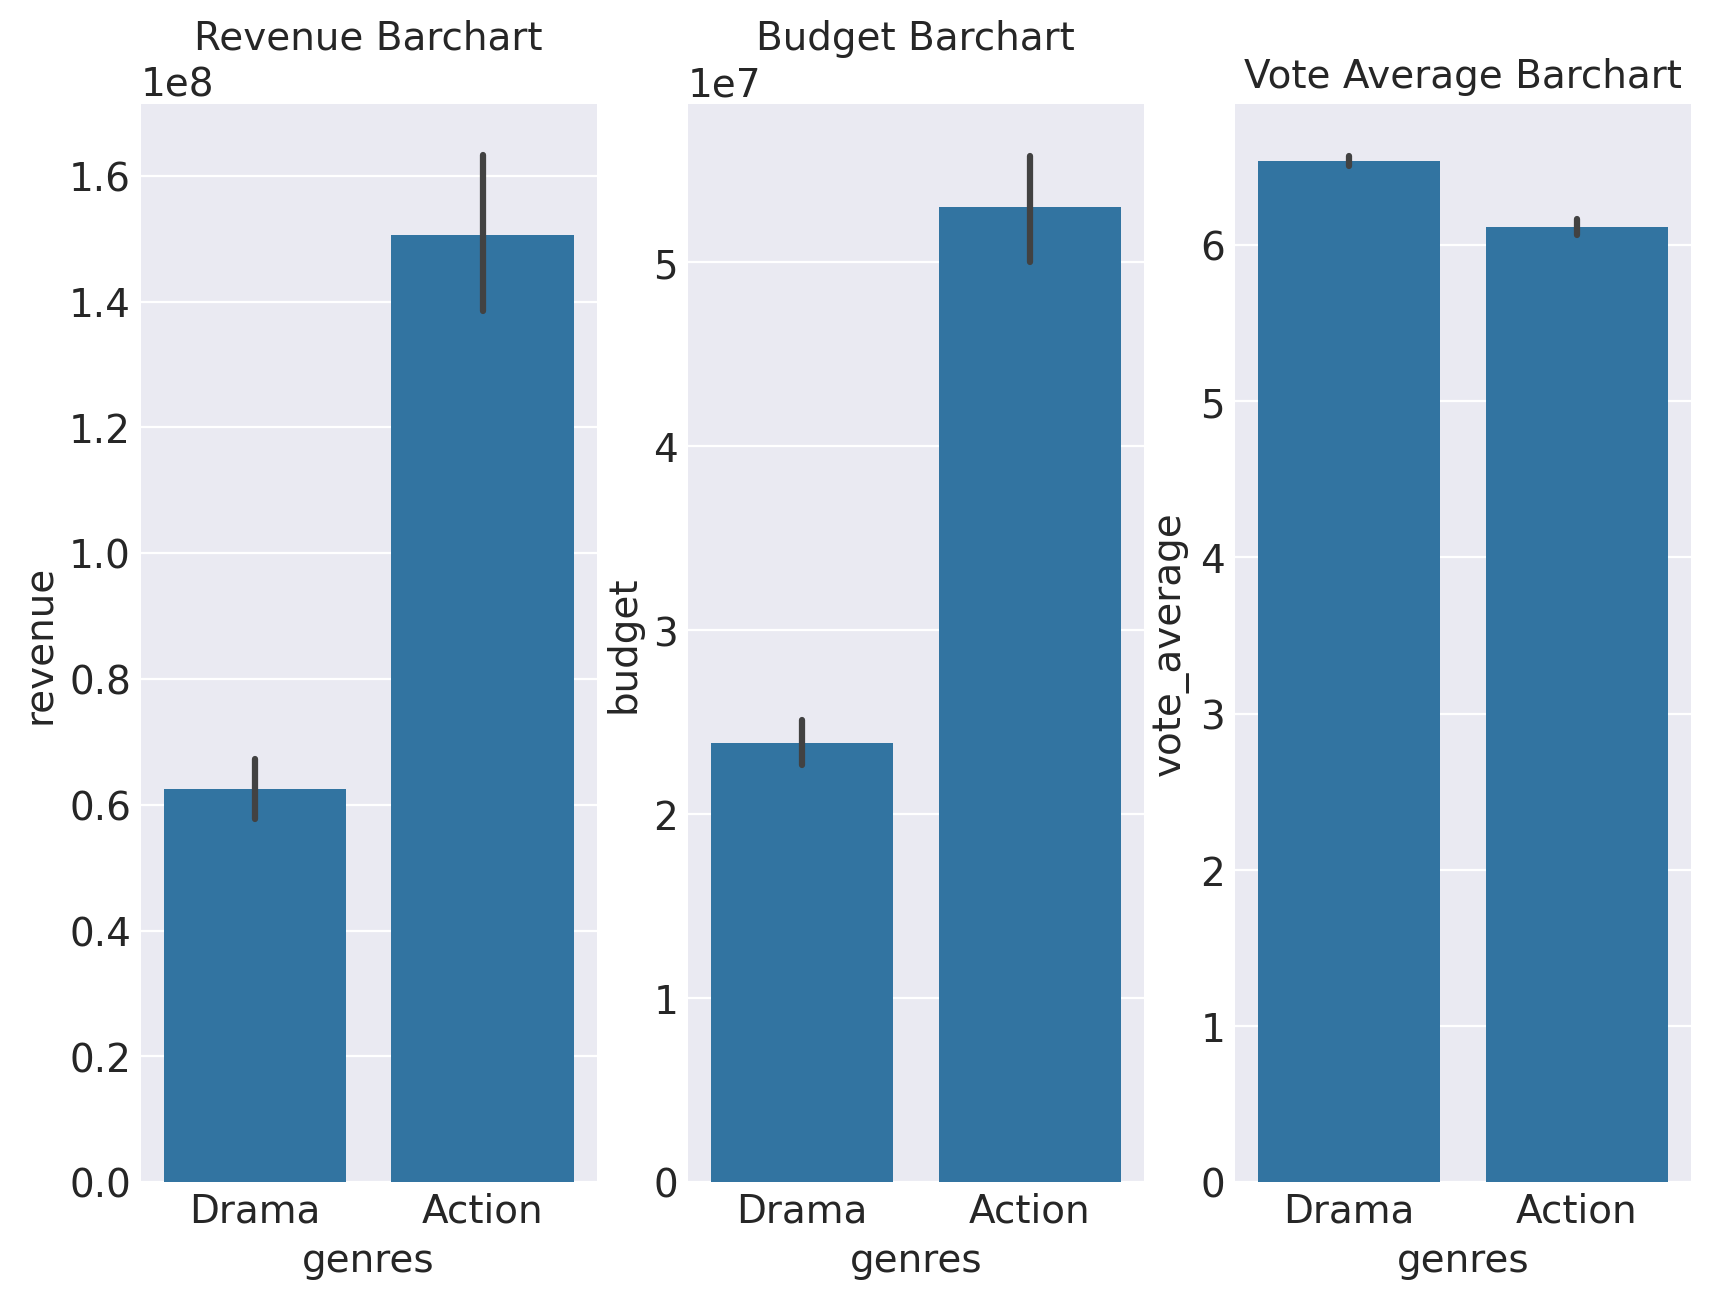

In [127]:
plot_barcharts(
    req_data, 'genres', ['revenue', 'budget', 'vote_average'], titles=['Revenue Barchart', 'Budget Barchart', 'Vote Average Barchart'])

From the barcharts we can make the following observations:
- Drama movies in average produce half the revenue and have half the budget
- Drama movies receive on average higher vote averages than Action movies
- From the confidence intervals, we can see that ew have more Drama movies in our dataset, hence our confidence intervals are narrower

We can confirm our third observation, by seeing how many movies are in each category.

In [128]:
grouped = req_data.groupby('genres')
grouped.count()

,id,revenue,budget,vote_average
genres,,,,
Action,1253,1253,1253,1253
Drama,2227,2227,2227,2227


Since Drama movies are overrepresented in our dataset, and t-test requires similar sample sizes, we will sample at random some of the Drama movies. We will produce again our barcharts, to see if anything changed significantly.

In [129]:
drama_sampled = grouped.get_group('Drama').sample(1253)
action = grouped.get_group('Action')

In [130]:
together = pd.concat([drama_sampled, action])
together.shape

(2506, 5)

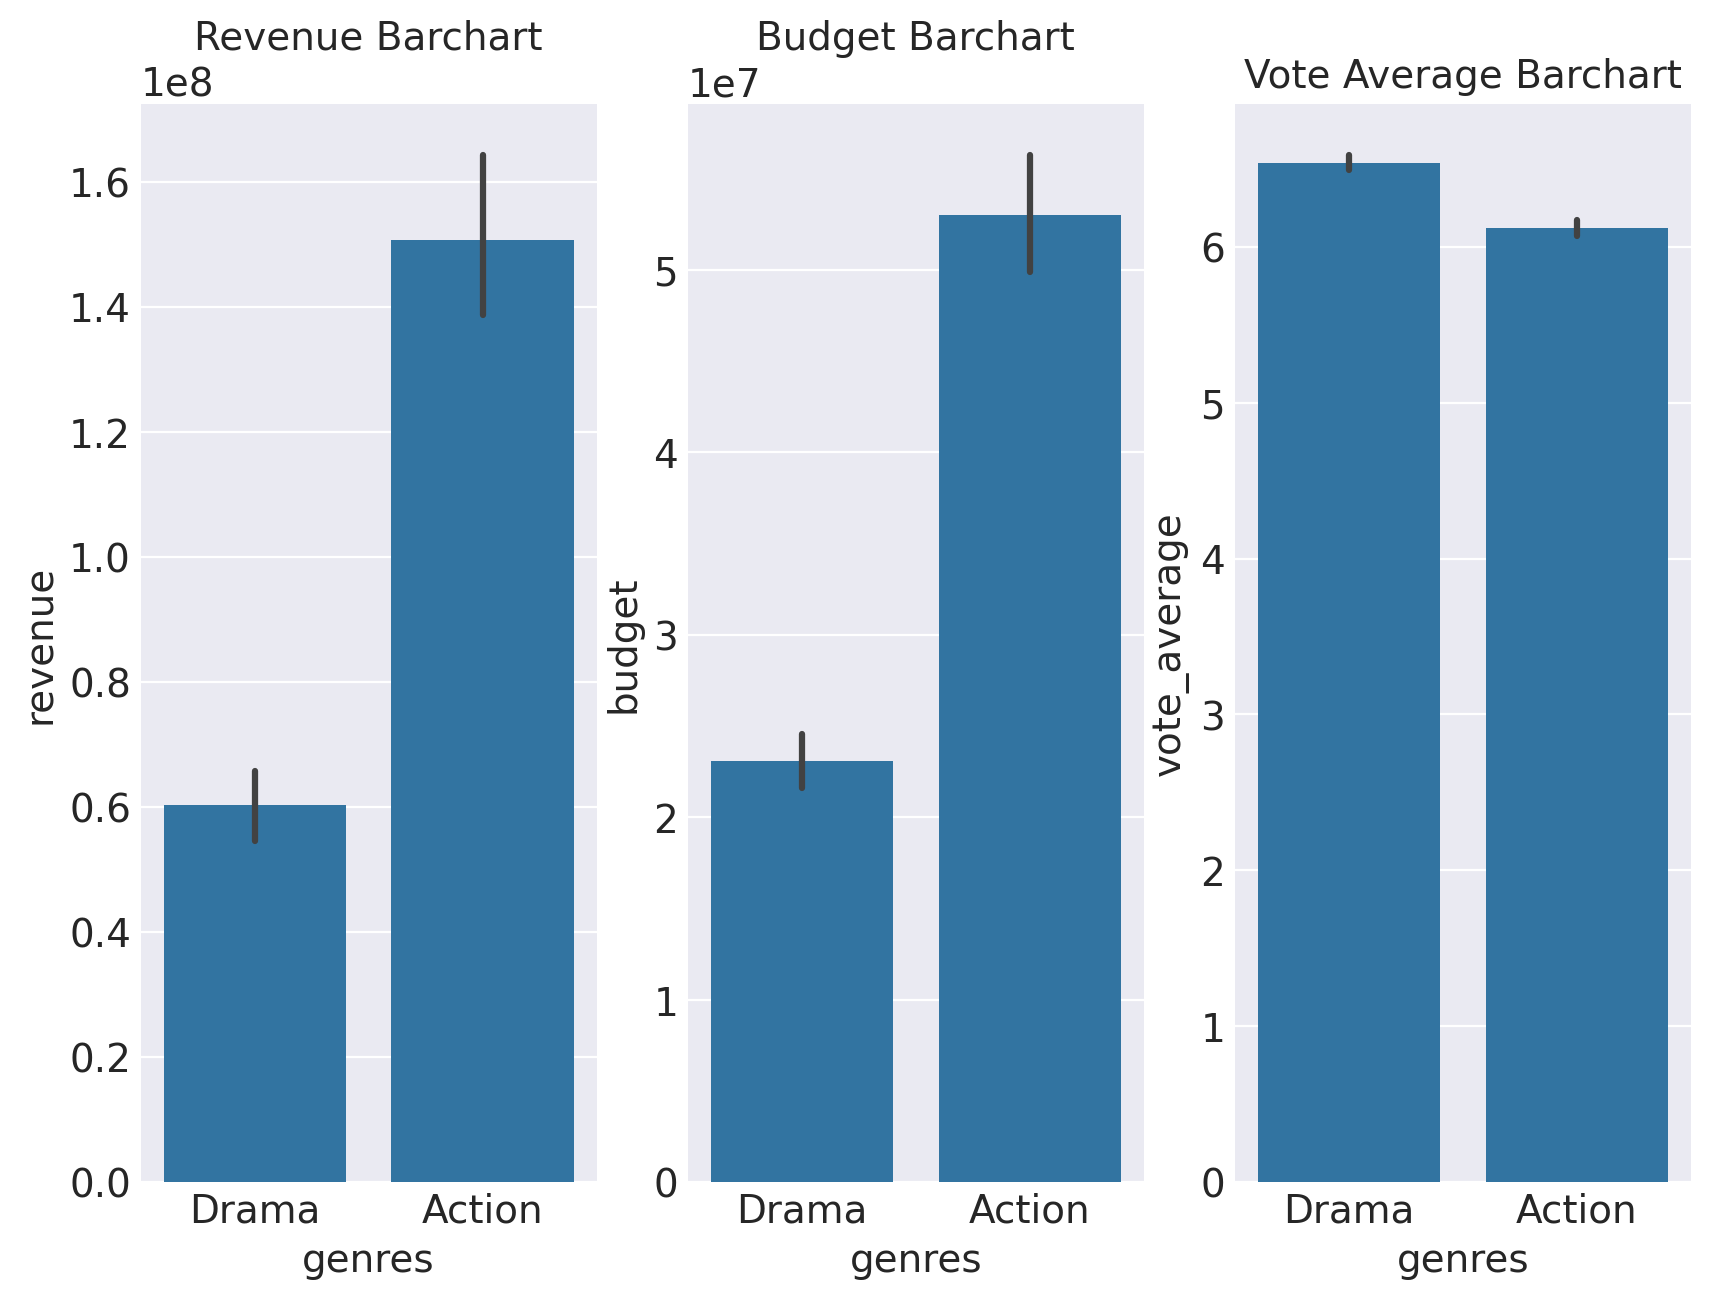

In [131]:
plot_barcharts(
        together, 'genres', ['revenue', 'budget', 'vote_average'], titles=['Revenue Barchart', 'Budget Barchart', 'Vote Average Barchart'])

As we see, even when we sampled, the barplots did not change to any visible level. When doing the t-test, we will perform it twice, to see if there are changes there.

In [132]:
from scipy.stats import ttest_ind

In [137]:
#req_data = req_data.groupby('genres')
#req_data = req_data.groupby('genres')
#together = together.groupby('genres')

print('Revenue')
print(ttest_ind(req_data.get_group('Action')['revenue'], req_data.get_group('Drama')['revenue']))
print(ttest_ind(together.get_group('Action')['revenue'], together.get_group('Drama')['revenue']))
print('\n')

print('Budget')
print(ttest_ind(req_data.get_group('Action')['budget'], req_data.get_group('Drama')['budget']))
print(ttest_ind(together.get_group('Action')['budget'], together.get_group('Drama')['budget']))
print('\n')

print('Vote Average')
print(ttest_ind(req_data.get_group('Action')['vote_average'], req_data.get_group('Drama')['vote_average']))
print(ttest_ind(together.get_group('Action')['vote_average'], together.get_group('Drama')['vote_average']))

Revenue
TtestResult(statistic=np.float64(14.780503175229157), pvalue=np.float64(5.4334658991316145e-48), df=np.float64(3478.0))
TtestResult(statistic=np.float64(12.229721921715518), pvalue=np.float64(1.9026126296669498e-33), df=np.float64(2504.0))


Budget
TtestResult(statistic=np.float64(20.471006120190406), pvalue=np.float64(4.947325928733611e-88), df=np.float64(3478.0))
TtestResult(statistic=np.float64(17.139810261385605), pvalue=np.float64(2.352081480730052e-62), df=np.float64(2504.0))


Vote Average
TtestResult(statistic=np.float64(-13.985984036755713), pvalue=np.float64(2.7649854253352934e-43), df=np.float64(3478.0))
TtestResult(statistic=np.float64(-12.06673453770839), pvalue=np.float64(1.249744395652268e-32), df=np.float64(2504.0))


Looking at the p-values of our test, with significance level $a=0.05$, we can reject our null hypothesis of our test, meaning that the mean values of our variables in the two different genres have a significant statistical difference. It is interesting to see that our tests produce also high t-values, and especially our test for vote average, produces large negative t-values.

## Step 7 - "Women directors have smaller budgets than male directors"

We will now investigate if women directors have smaller budgets than male directors. To do this, we will examine their difference in mean values, so our approach will be the same as the above, using a Student t-test. 

In [138]:
joined_df

,id,title,vote_count,duration,vote_average,revenue,budget,release_date,genres,log_votes,crew,job,gender
0,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Animation,8.597113,"[Director, 2]",Director,male
1,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Comedy,8.597113,"[Director, 2]",Director,male
2,862,Toy Story,5415,81,7.7,373554033,30000000,1995-10-30,Family,8.597113,"[Director, 2]",Director,male
3,8844,Jumanji,2413,104,6.9,262797249,65000000,1995-12-15,Adventure,7.789040,"[Director, 2]",Director,male
4,8844,Jumanji,2413,104,6.9,262797249,65000000,1995-12-15,Fantasy,7.789040,"[Director, 2]",Director,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14594,24049,Sivaji: The Boss,25,185,6.9,19000000,12000000,2007-06-14,Action,3.258097,"[Director, 2]",Director,male
14595,24049,Sivaji: The Boss,25,185,6.9,19000000,12000000,2007-06-14,Comedy,3.258097,"[Director, 2]",Director,male
14596,24049,Sivaji: The Boss,25,185,6.9,19000000,12000000,2007-06-14,Drama,3.258097,"[Director, 2]",Director,male
14599,63281,Pro Lyuboff,3,107,4.0,1268793,2000000,2010-09-30,Romance,1.386294,"[Director, 1]",Director,female


We will run also two tests again, one for equal samples and one with all our data.

In [140]:
gender_groups = joined_df.groupby('gender')
male_group_budget = gender_groups.get_group('male')
female_group_budget = gender_groups.get_group('female')

gender_groups['budget'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,558.0,3.474316e+07,4.384672e+07,7.0,7000000.0,15000000.0,40000000.0,185000000.0
male,11951.0,3.857823e+07,4.539463e+07,1.0,8000000.0,22000000.0,50000000.0,380000000.0


In [141]:
male_group_sampled = male_group_budget.sample(n=558)

In [143]:
print(male_group_budget['budget'].describe())
print(female_group_budget['budget'].describe())

count    1.195100e+04
mean     3.857823e+07
std      4.539463e+07
min      1.000000e+00
25%      8.000000e+06
50%      2.200000e+07
75%      5.000000e+07
max      3.800000e+08
Name: budget, dtype: float64
count    5.580000e+02
mean     3.474316e+07
std      4.384672e+07
min      7.000000e+00
25%      7.000000e+06
50%      1.500000e+07
75%      4.000000e+07
max      1.850000e+08
Name: budget, dtype: float64


In [144]:
print(male_group_sampled['budget'].describe())
print(female_group_budget['budget'].describe())

count    5.580000e+02
mean     4.148770e+07
std      4.742739e+07
min      5.000000e+00
25%      1.000000e+07
50%      2.500000e+07
75%      6.000000e+07
max      2.500000e+08
Name: budget, dtype: float64
count    5.580000e+02
mean     3.474316e+07
std      4.384672e+07
min      7.000000e+00
25%      7.000000e+06
50%      1.500000e+07
75%      4.000000e+07
max      1.850000e+08
Name: budget, dtype: float64


We see difference in the means in both cases, but in the mean budget of the male group, the sampled mean has a larger mean.

In [145]:
print('Student t-test for all our data')
ttest_ind(male_group_budget['budget'],female_group_budget['budget'])

Student t-test for all our data


TtestResult(statistic=np.float64(1.9535528691536772), pvalue=np.float64(0.05077638139672902), df=np.float64(12507.0))

In [146]:
print('Student t-test for the sampled male data')
ttest_ind(male_group_sampled['budget'],female_group_budget['budget'])

Student t-test for the sampled male data


TtestResult(statistic=np.float64(2.466623534511941), pvalue=np.float64(0.013789022539583374), df=np.float64(1114.0))

With significance level $a=0.05$, we can not reject the null hypothesis in the first case, where in the first case we have diffenrent sample sizes, while we can can reject it in the second case, where we have the same sample sizes, meaning that on average, women directors have smaller budgets than male directors.

## Step 8 - "Male movie directors generate more revenue that female directors"

We will again run a Student t-test for the above.

In [218]:
groups_gender_revenue = joined_df.groupby('gender')['revenue']
groups_gender_revenue.describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,558.0,1.072285e+08,1.889097e+08,4.0,5054374.5,30159381.5,100076342.0,1.274219e+09
male,11951.0,1.155991e+08,1.955023e+08,1.0,10785801.0,41895491.0,130786397.0,2.787965e+09


In [219]:
males_group_revenue = groups_gender_revenue.get_group('male')
females_group_revenue = groups_gender_revenue.get_group('female')

print(f'Male group revenue mean: {males_group_revenue.mean():.2f}, std: {males_group_revenue.std():.2f}')
print(f'Female group revenue mean: {females_group_revenue.mean():.2f}, std: {females_group_revenue.std():.2f}')

Male group revenue mean: 115599052.38, std: 195502297.36
Female group revenue mean: 107228479.46, std: 188909728.48


In [220]:
ttest_ind(males_group_revenue, females_group_revenue)

TtestResult(statistic=np.float64(0.9900415228044175), pvalue=np.float64(0.32217297672531775), df=np.float64(12507.0))

In [221]:
males_group_revenue_sampled = groups_gender_revenue.get_group('male').sample(558)
females_group_revenue = groups_gender_revenue.get_group('female')

print(f'Male group revenue mean: {males_group_revenue_sampled.mean():.2f}, std: {males_group_revenue_sampled.std():.2f}')
print(f'Female group revenue mean: {females_group_revenue.mean():.2f}, std: {females_group_revenue.std():.2f}')

Male group revenue mean: 131789865.51, std: 229559095.51
Female group revenue mean: 107228479.46, std: 188909728.48


In [222]:
ttest_ind(males_group_revenue_sampled, females_group_revenue)

TtestResult(statistic=np.float64(1.9515626426031374), pvalue=np.float64(0.051240481236158764), df=np.float64(1114.0))

In the two tests, with significance level $a=0.05$, we can not reject the null hypothesis, because our tests procude p-values greater than our significance level.

So, we can not confirm our statement, and hence the difference in the mean budgets between of male and female directors are negleballe.